# Informe 4 — Clasificación avanzada de abandono de clientes

### Empresa: NovaConecta

### Integrantes del equipo:

- Angel Luis Kallpa De La Cruz Meza
- Marco Renato Castilla Huanca
- Edu Sanchez Gotea
- David Joel Aldana Chavez
- Marcos Luis Basualdo Ale
- Leonardo Vera Rodriguez
- Gabriel Poma Gutierrez

### Objetivo general

Construir, comparar y evaluar modelos de clasificación supervisada que permitan predecir si un cliente de NovaConecta abandonará el servicio, aplicando análisis exploratorio, preprocesamiento sin fuga de información, balanceo de clases, validación cruzada, ajuste de hiperparámetros e interpretación de resultados para proponer acciones de retención.

## Descripción del caso y del dataset

### Contexto del problema de negocio

NovaConecta es una empresa ficticia de telecomunicaciones que ofrece planes Básico, Estándar y Premium. La pérdida de clientes o **churn** afecta los ingresos y aumenta los costos de captación, por lo que la empresa necesita identificar con anticipación a quienes tienen mayor riesgo de abandonar.

El problema se formula como una **clasificación binaria**:

- `0`: el cliente permanece (`No`).
- `1`: el cliente abandona (`Si`).

Detectar correctamente la clase positiva permitirá priorizar campañas de retención, revisar casos con baja satisfacción y atender clientes con señales de fricción. Los falsos negativos serán especialmente importantes porque representan clientes que abandonan sin haber sido identificados por el modelo.

El dataset sintético de NovaConecta representa **1200 clientes** mediante **13 columnas** relacionadas con identificación, plan contratado, antigüedad, consumo, interacciones con soporte, cargo mensual, satisfacción, valor de vida y abandono. Para el modelado se utiliza `abandono` como objetivo binario y se excluyen los campos identificativos, redundantes o que producen fuga de información.

## Generación/carga de datos sintéticos

### Importación de librerías y configuración reproducible

In [1]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print(f"Semilla configurada: {SEED}")
print(f"pandas: {pd.__version__}")

Semilla configurada: 42
pandas: 3.0.3


### Localización robusta y carga del dataset

Se buscan rutas relativas compatibles con las formas habituales de ejecución:

- Desde la carpeta raíz del repositorio.
- Desde `notebooks` en Visual Studio Code.
- Desde una clonación ubicada en `/content` en Google Colab.

Solo si no existe una copia local se utiliza la dirección *raw* del repositorio como respaldo. De esta forma, el notebook no depende de una ruta absoluta específica del equipo del desarrollador.

In [2]:
DATASET_NAME = "dataset_novaconecta.csv"

# Se buscan únicamente ubicaciones relativas al directorio actual y sus padres.
# Esto funciona desde la raíz del repositorio, desde notebooks/ y en Colab
# después de clonar el proyecto y ubicarse dentro de su carpeta.
current = Path.cwd().resolve()
candidates = []
for base in [current, *current.parents]:
    candidates.extend([
        base / "bloque_b_python" / "data" / DATASET_NAME,
        base / "data" / DATASET_NAME,
    ])

data_source = next((path for path in candidates if path.exists()), None)

if data_source is None:
    raise FileNotFoundError(
        "No se encontró dataset_novaconecta.csv. Ejecute el notebook desde la "
        "raíz del repositorio o desde notebooks. En Colab, clone "
        "primero el repositorio y cambie el directorio de trabajo a su raíz."
    )

df = pd.read_csv(data_source, encoding="utf-8")

print(f"Dataset cargado desde: {data_source.relative_to(repo_root) if 'repo_root' in globals() and data_source.is_relative_to(repo_root) else data_source}")
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dataset cargado desde: E:\PROYECTO IA\Proyecto_IA\bloque_b_python\data\dataset_novaconecta.csv
Dimensiones: 1200 filas x 13 columnas


,id_cliente,nombre_cliente,ciudad,fecha_registro,edad,plan_contratado,antiguedad_meses,uso_datos_gb,num_llamadas_soporte,cargo_mensual,satisfaccion_cliente,valor_vida_cliente,abandono
0,NC-00001,Albano Llopis Hierro,Alicante,2023-12-04,56,Basico,31,16.4,4,30.13,4,1321.71,No
1,NC-00002,Buenaventura de Bonet,Badajoz,2026-05-11,69,Estandar,2,48.2,1,45.18,8,174.05,Si
2,NC-00003,Ileana Antón-Andrés,Valencia,2025-05-09,46,Estandar,14,51.0,2,59.50,6,844.68,Si
3,NC-00004,César Guerrero Vazquez,Palencia,2021-09-27,32,Estandar,57,31.4,1,63.76,8,4427.04,No
4,NC-00005,Alba Mar Flor Rivas,Jaén,2023-04-09,60,Estandar,39,44.3,2,59.46,7,3024.14,No


## Análisis exploratorio (EDA)

### Revisión inicial de calidad de datos

In [3]:
print("Información general del DataFrame:\n")
df.info()

Información general del DataFrame:

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_cliente            1200 non-null   str    
 1   nombre_cliente        1200 non-null   str    
 2   ciudad                1200 non-null   str    
 3   fecha_registro        1200 non-null   str    
 4   edad                  1200 non-null   int64  
 5   plan_contratado       1200 non-null   str    
 6   antiguedad_meses      1200 non-null   int64  
 7   uso_datos_gb          1175 non-null   float64
 8   num_llamadas_soporte  1200 non-null   int64  
 9   cargo_mensual         1200 non-null   float64
 10  satisfaccion_cliente  1200 non-null   int64  
 11  valor_vida_cliente    1200 non-null   float64
 12  abandono              1200 non-null   str    
dtypes: float64(3), int64(4), str(6)
memory usage: 122.0 KB


In [4]:
resumen_columnas = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "no_nulos": df.notna().sum(),
    "nulos": df.isna().sum(),
    "porcentaje_nulos": (df.isna().mean() * 100).round(2),
    "valores_unicos": df.nunique(dropna=False),
})

resumen_columnas

,tipo,no_nulos,nulos,porcentaje_nulos,valores_unicos
id_cliente,str,1200,0,0.00,1200
nombre_cliente,str,1200,0,0.00,1200
ciudad,str,1200,0,0.00,52
fecha_registro,str,1200,0,0.00,912
edad,int64,1200,0,0.00,57
plan_contratado,str,1200,0,0.00,3
antiguedad_meses,int64,1200,0,0.00,60
uso_datos_gb,float64,1175,25,2.08,600
num_llamadas_soporte,int64,1200,0,0.00,10
cargo_mensual,float64,1200,0,0.00,1063


In [5]:
resumen_estadistico = df.describe(include="all").T
resumen_estadistico

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_cliente,1200,1200,NC-00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nombre_cliente,1200,1200,Albano Llopis Hierro,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ciudad,1200,52,Melilla,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha_registro,1200,912,2022-10-21,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
edad,1200.0,NaN,NaN,NaN,46.3175,16.451157,18.0,33.0,46.0,61.0,74.0
plan_contratado,1200,3,Basico,520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
antiguedad_meses,1200.0,NaN,NaN,NaN,29.984167,17.428819,1.0,15.0,30.0,45.0,60.0
uso_datos_gb,1175.0,NaN,NaN,NaN,39.231404,29.804066,3.4,16.2,31.0,50.25,155.1
num_llamadas_soporte,1200.0,NaN,NaN,NaN,2.368333,1.619109,0.0,1.0,2.0,3.0,9.0
cargo_mensual,1200.0,NaN,NaN,NaN,54.755525,26.935812,15.16,32.7275,54.595,63.7925,263.84


In [6]:
filas_duplicadas = int(df.duplicated().sum())
ids_duplicados = int(df["id_cliente"].duplicated().sum())

print(f"Filas completamente duplicadas: {filas_duplicadas}")
print(f"Identificadores duplicados: {ids_duplicados}")

assert filas_duplicadas == 0, "Se encontraron filas duplicadas que deben revisarse."
assert ids_duplicados == 0, "Se encontraron identificadores repetidos."

Filas completamente duplicadas: 0
Identificadores duplicados: 0


In [7]:
tabla_nulos = (
    df.isna()
      .sum()
      .rename("cantidad_nulos")
      .to_frame()
      .assign(porcentaje=lambda x: (x["cantidad_nulos"] / len(df) * 100).round(2))
      .query("cantidad_nulos > 0")
)

tabla_nulos

,cantidad_nulos,porcentaje
uso_datos_gb,25,2.08


#### Hallazgos de calidad

- El dataset contiene **1200 clientes y 13 variables**.
- No existen filas ni identificadores duplicados.
- `uso_datos_gb` presenta 25 valores faltantes, equivalentes aproximadamente al 2.08 % de las observaciones.
- La imputación se realizará con la mediana, pero se aprenderá únicamente a partir del conjunto de entrenamiento mediante `SimpleImputer`.
- No se eliminan filas en esta etapa para evitar perder información útil y modificar artificialmente la distribución de clases.

### Análisis exploratorio orientado a clasificación

In [8]:
distribucion_abandono = pd.DataFrame({
    "cantidad": df["abandono"].value_counts(),
    "porcentaje": (df["abandono"].value_counts(normalize=True) * 100).round(2),
})

distribucion_abandono

,cantidad,porcentaje
abandono,,
No,742,61.83
Si,458,38.17


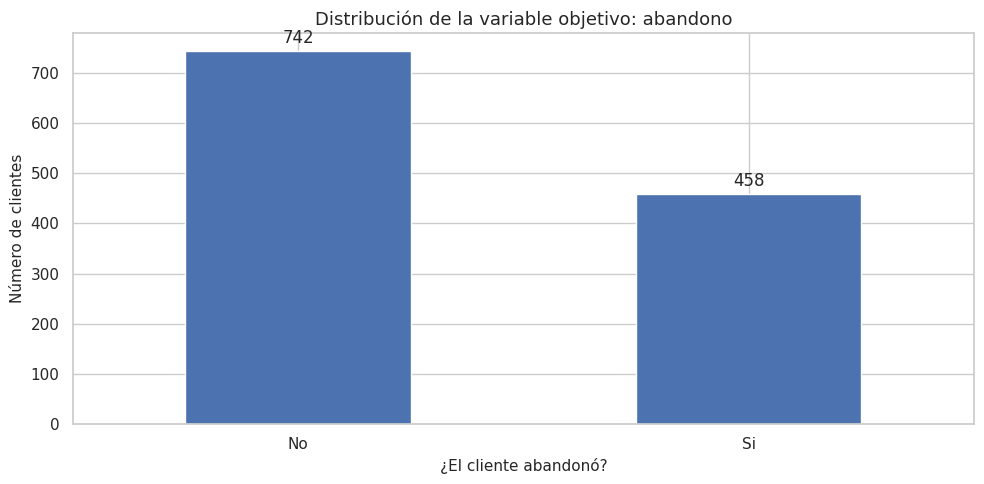

In [9]:
conteos = df["abandono"].value_counts().reindex(["No", "Si"])
ax = conteos.plot(kind="bar", rot=0)
ax.set_title("Distribución de la variable objetivo: abandono")
ax.set_xlabel("¿El cliente abandonó?")
ax.set_ylabel("Número de clientes")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

#### Análisis del desbalance

La clase `No` representa aproximadamente el 61.83 % y la clase `Si` el 38.17 %. Existe un **desbalance moderado**, pero no lo suficientemente extremo como para justificar SMOTE de manera automática.

En etapas posteriores se compararán tres escenarios usando validación cruzada estratificada:

1. Sin balanceo.
2. Pesos de clase (`class_weight="balanced"`) en modelos compatibles.
3. SMOTE aplicado exclusivamente dentro del conjunto de entrenamiento y de cada partición de validación cruzada.

En esta primera parte no se modifica la distribución original.

In [10]:
tasa_plan = pd.crosstab(
    df["plan_contratado"],
    df["abandono"],
    normalize="index"
).mul(100).round(2)

tasa_plan

abandono,No,Si
plan_contratado,,
Basico,69.42,30.58
Estandar,60.62,39.38
Premium,46.93,53.07


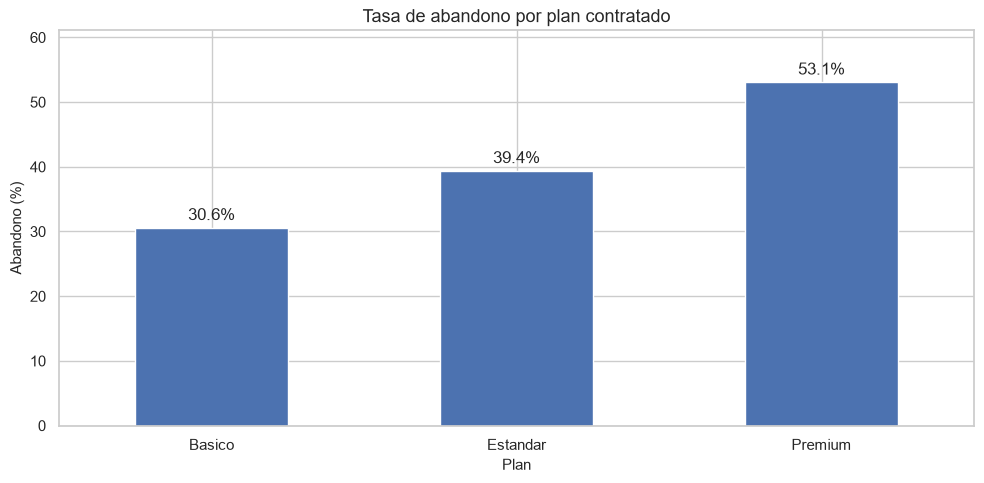

In [9]:
tasa_plan_plot = (
    df.groupby("plan_contratado", observed=False)["abandono"]
      .apply(lambda s: (s == "Si").mean() * 100)
      .reset_index(name="tasa_abandono")
)

tasa_plan_ordenada = (
    tasa_plan_plot
    .set_index("plan_contratado")
    .reindex(["Basico", "Estandar", "Premium"])["tasa_abandono"]
)

ax = tasa_plan_ordenada.plot(kind="bar", rot=0)
ax.set_title("Tasa de abandono por plan contratado")
ax.set_xlabel("Plan")
ax.set_ylabel("Abandono (%)")
ax.set_ylim(0, max(60, tasa_plan_ordenada.max() + 8))

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

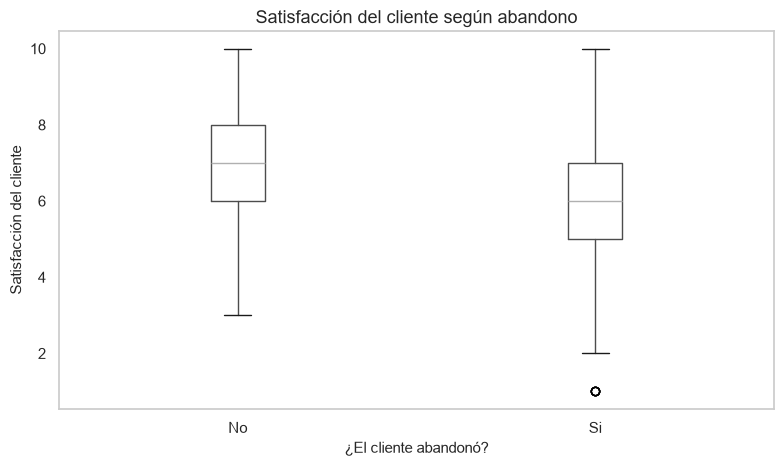

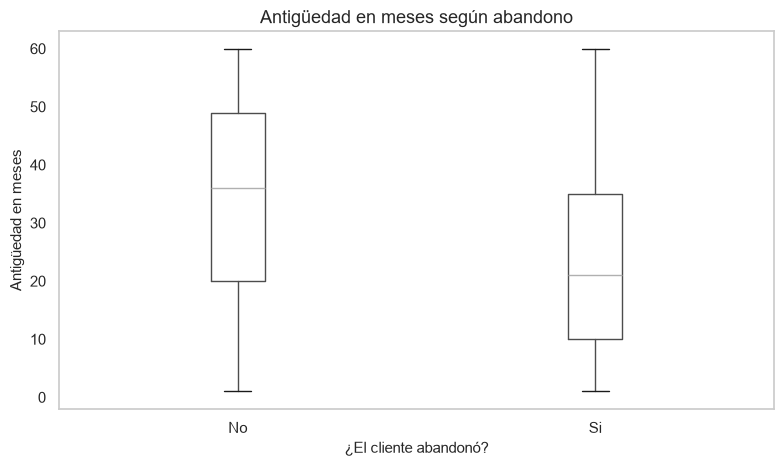

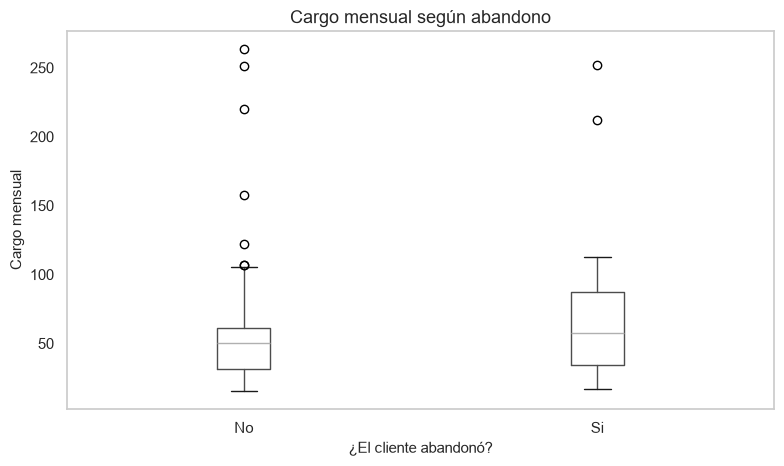

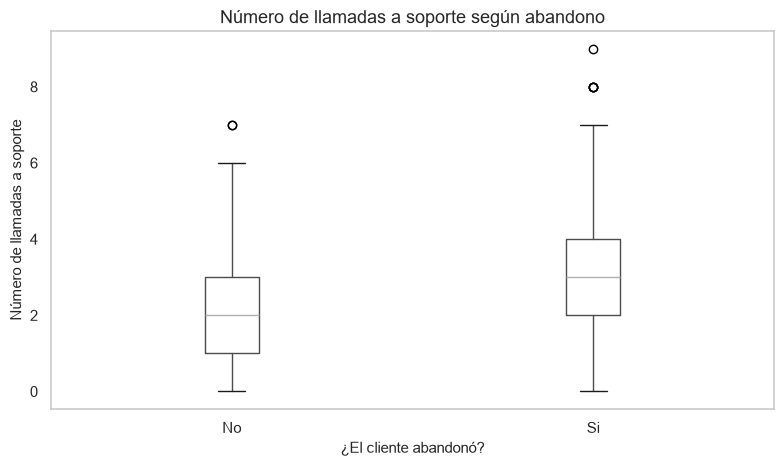

In [12]:
variables_clave = {
    "satisfaccion_cliente": "Satisfacción del cliente",
    "antiguedad_meses": "Antigüedad en meses",
    "cargo_mensual": "Cargo mensual",
    "num_llamadas_soporte": "Número de llamadas a soporte",
}

for variable, etiqueta in variables_clave.items():
    ax = df.boxplot(
        column=variable,
        by="abandono",
        grid=False,
        figsize=(8, 5)
    )

    ax.set_title(f"{etiqueta} según abandono")
    ax.set_xlabel("¿El cliente abandonó?")
    ax.set_ylabel(etiqueta)

    plt.suptitle("")
    plt.tight_layout()
    plt.show()

In [11]:
media_por_clase = (
    df.groupby("abandono", observed=False)[variables_clave]
      .mean()
      .round(2)
)

media_por_clase

,satisfaccion_cliente,antiguedad_meses,cargo_mensual,num_llamadas_soporte
abandono,,,,
No,7.10,33.87,51.63,1.98
Si,5.62,23.70,59.82,2.99


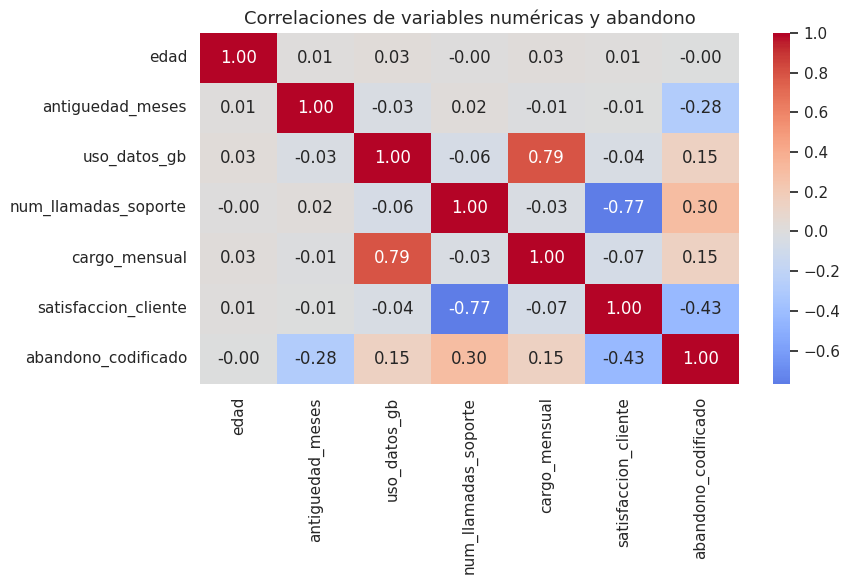

In [14]:
correlation_df = df[
    [
        "edad",
        "antiguedad_meses",
        "uso_datos_gb",
        "num_llamadas_soporte",
        "cargo_mensual",
        "satisfaccion_cliente",
    ]
].copy()
correlation_df["abandono_codificado"] = df["abandono"].map({"No": 0, "Si": 1})

plt.figure(figsize=(9, 6))
sns.heatmap(
    correlation_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=False
)
plt.title("Correlaciones de variables numéricas y abandono")
plt.tight_layout()
plt.show()

#### Interpretación preliminar

Los gráficos se utilizan únicamente para comprender el dataset, no para seleccionar todavía un modelo final. Se espera observar mayor riesgo de abandono en clientes con menor satisfacción, menor antigüedad y cargos mensuales más elevados, porque esas variables participaron en la generación sintética del objetivo.

`edad` puede mostrar poca relación porque fue generada de manera independiente. Aun así, se conservará en la primera comparación porque es una variable disponible antes del abandono y no genera fuga de información.

## Preprocesamiento

### Identificación de data leakage

In [14]:
clv_por_abandono = (
    df.groupby("abandono", observed=False)["valor_vida_cliente"]
      .agg(["count", "mean", "median", "min", "max"])
      .round(2)
)

clv_por_abandono

,count,mean,median,min,max
abandono,,,,,
No,742,2341.89,1983.63,224.32,7434.89
Si,458,1391.49,1055.72,50.00,5861.24


#### ¿Por qué `valor_vida_cliente` no puede utilizarse como predictor?

El script generador calcula esta variable mediante una proyección que depende directamente de la respuesta que se desea predecir:

```python
proyeccion_meses = np.where(abandono == "Si", 0, 12)
valor_vida_cliente = cargo_mensual * (antiguedad_meses + proyeccion_meses)
```

Cuando el cliente abandona se agregan cero meses futuros; cuando permanece se agregan doce. Por ello, `valor_vida_cliente` ya contiene información de `abandono` y su inclusión produciría **data leakage**: el modelo recibiría indirectamente parte de la respuesta correcta.

La variable se puede mostrar con fines descriptivos, pero queda excluida de `X`, del preprocesamiento y de todos los modelos de clasificación.

### Selección de variables y codificación del objetivo

In [13]:
TARGET = "abandono"

FEATURES = [
    "edad",
    "plan_contratado",
    "antiguedad_meses",
    "uso_datos_gb",
    "num_llamadas_soporte",
    "cargo_mensual",
    "satisfaccion_cliente",
]

EXCLUDED_COLUMNS = [
    "id_cliente",            # Identificador único
    "nombre_cliente",        # Dato identificativo sin valor predictivo diseñado
    "ciudad",                # Alta cardinalidad y generación aleatoria
    "fecha_registro",        # Redundante con antiguedad_meses
    "valor_vida_cliente",    # Data leakage
]

X = df[FEATURES].copy()
y = df[TARGET].map({"No": 0, "Si": 1})

assert y.notna().all(), "La codificación del objetivo produjo valores nulos."
assert set(y.unique()) == {0, 1}, "La variable objetivo no quedó codificada como binaria."
assert "valor_vida_cliente" not in X.columns, "Se detectó la variable con leakage en X."
assert TARGET not in X.columns, "La variable objetivo no debe formar parte de X."

print(f"Variables predictoras ({len(FEATURES)}): {FEATURES}")
print(f"Variable objetivo: {TARGET} — 0=No, 1=Si")
print(f"Columnas excluidas: {EXCLUDED_COLUMNS}")

Variables predictoras (7): ['edad', 'plan_contratado', 'antiguedad_meses', 'uso_datos_gb', 'num_llamadas_soporte', 'cargo_mensual', 'satisfaccion_cliente']
Variable objetivo: abandono — 0=No, 1=Si
Columnas excluidas: ['id_cliente', 'nombre_cliente', 'ciudad', 'fecha_registro', 'valor_vida_cliente']


#### Justificación de la selección

| Variable | Decisión | Justificación |
|---|---|---|
| `edad` | Incluir | Variable demográfica disponible antes del evento. |
| `plan_contratado` | Incluir | Determina características de consumo y precio. |
| `antiguedad_meses` | Incluir | Representa permanencia y evita usar la fecha en bruto. |
| `uso_datos_gb` | Incluir | Resume comportamiento de consumo. |
| `num_llamadas_soporte` | Incluir | Señal de fricción y necesidad de asistencia. |
| `cargo_mensual` | Incluir | Variable económica vinculada al abandono. |
| `satisfaccion_cliente` | Incluir | Señal directa de experiencia del cliente. |
| `id_cliente` | Excluir | Identificador único sin significado predictivo. |
| `nombre_cliente` | Excluir | Texto identificativo generado aleatoriamente. |
| `ciudad` | Excluir | 52 categorías generadas sin relación diseñada con el abandono. |
| `fecha_registro` | Excluir | Información redundante con `antiguedad_meses`. |
| `valor_vida_cliente` | Excluir | Su cálculo utiliza directamente `abandono`. |

### División estratificada de entrenamiento y prueba

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

split_summary = pd.DataFrame({
    "conjunto": ["Entrenamiento", "Prueba"],
    "filas": [len(X_train), len(X_test)],
    "clase_0": [int((y_train == 0).sum()), int((y_test == 0).sum())],
    "clase_1": [int((y_train == 1).sum()), int((y_test == 1).sum())],
    "% clase_1": [
        round((y_train == 1).mean() * 100, 2),
        round((y_test == 1).mean() * 100, 2),
    ],
})

split_summary

,conjunto,filas,clase_0,clase_1,% clase_1
0,Entrenamiento,960,594,366,38.12
1,Prueba,240,148,92,38.33


In [18]:
assert len(X_train) == 960, "El entrenamiento debe contener el 80 % de 1200 registros."
assert len(X_test) == 240, "La prueba debe contener el 20 % de 1200 registros."
assert X_train.index.intersection(X_test.index).empty, "Train y test comparten índices."
assert abs(y_train.mean() - y_test.mean()) < 0.01, "La estratificación no preservó adecuadamente la proporción."

print("Verificaciones de división superadas:")
print("- Train y test no comparten registros.")
print("- La proporción de la clase positiva se conserva.")
print("- Todavía no se ha aplicado imputación, escalamiento, One-Hot Encoding ni SMOTE.")

Verificaciones de división superadas:
- Train y test no comparten registros.
- La proporción de la clase positiva se conserva.
- Todavía no se ha aplicado imputación, escalamiento, One-Hot Encoding ni SMOTE.


La separación se realiza **antes** de aprender medianas, medias, desviaciones o categorías. El conjunto de prueba se reserva para evaluar la capacidad de generalización y no debe utilizarse para decidir el modelo, el balanceo ni los hiperparámetros.

### Identificación de variables numéricas y categóricas

In [19]:
NUMERIC_FEATURES = [
    "edad",
    "antiguedad_meses",
    "uso_datos_gb",
    "num_llamadas_soporte",
    "cargo_mensual",
    "satisfaccion_cliente",
]

CATEGORICAL_FEATURES = ["plan_contratado"]

assert set(NUMERIC_FEATURES + CATEGORICAL_FEATURES) == set(FEATURES)

print("Variables numéricas:", NUMERIC_FEATURES)
print("Variables categóricas:", CATEGORICAL_FEATURES)

Variables numéricas: ['edad', 'antiguedad_meses', 'uso_datos_gb', 'num_llamadas_soporte', 'cargo_mensual', 'satisfaccion_cliente']
Variables categóricas: ['plan_contratado']


### Pipeline de preprocesamiento

#### Variables numéricas

1. `SimpleImputer(strategy="median")` para completar los valores faltantes de `uso_datos_gb` usando únicamente el entrenamiento.
2. `StandardScaler()` para estandarizar las escalas. Esta elección mantiene coherencia con el Informe 3 y es especialmente importante para Regresión Logística, KNN y SVC.

Aunque existen ocho cargos extremos introducidos deliberadamente, no se eliminarán ni winsorizarán antes de la división. En una etapa posterior se podrá comparar `StandardScaler` con `RobustScaler` mediante validación cruzada si los modelos sensibles a la escala muestran inestabilidad.

#### Variable categórica

1. Imputación por moda como protección ante futuros valores faltantes.
2. `OneHotEncoder(handle_unknown="ignore")` para transformar el plan sin asignar un orden artificial y permitir categorías no vistas en una ejecución futura.

In [20]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, NUMERIC_FEATURES),
        ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_na

### Ajuste controlado del preprocesamiento

Para comprobar que el pipeline funciona, se ajusta exclusivamente con `X_train`. El conjunto de prueba solo se transforma utilizando los parámetros previamente aprendidos.

Esto no constituye todavía el entrenamiento de un clasificador: únicamente valida la preparación de datos que luego se integrará dentro de cada pipeline de modelo y dentro de la validación cruzada.

In [21]:
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print(f"Forma original de X_train: {X_train.shape}")
print(f"Forma transformada de X_train: {X_train_prepared.shape}")
print(f"Forma transformada de X_test: {X_test_prepared.shape}")
print(f"Características resultantes ({len(feature_names)}):")
print(list(feature_names))

Forma original de X_train: (960, 7)
Forma transformada de X_train: (960, 9)
Forma transformada de X_test: (240, 9)
Características resultantes (9):
['edad', 'antiguedad_meses', 'uso_datos_gb', 'num_llamadas_soporte', 'cargo_mensual', 'satisfaccion_cliente', 'plan_contratado_Basico', 'plan_contratado_Estandar', 'plan_contratado_Premium']


In [22]:
train_median = X_train["uso_datos_gb"].median()
full_median = X["uso_datos_gb"].median()

numeric_imputer = preprocessor.named_transformers_["numeric"].named_steps["imputer"]
usage_index = NUMERIC_FEATURES.index("uso_datos_gb")
learned_median = numeric_imputer.statistics_[usage_index]

scaler = preprocessor.named_transformers_["numeric"].named_steps["scaler"]
observations_seen = int(np.max(np.atleast_1d(scaler.n_samples_seen_)))

verification = pd.DataFrame({
    "comprobacion": [
        "Mediana de uso_datos_gb en entrenamiento",
        "Mediana aprendida por SimpleImputer",
        "Mediana de uso_datos_gb en dataset completo (solo referencia)",
        "Filas observadas por StandardScaler durante fit",
        "Filas del conjunto de entrenamiento",
    ],
    "valor": [
        train_median,
        learned_median,
        full_median,
        observations_seen,
        len(X_train),
    ],
})

verification

,comprobacion,valor
0,Mediana de uso_datos_gb en entrenamiento,30.15
1,Mediana aprendida por SimpleImputer,30.15
2,Mediana de uso_datos_gb en dataset completo (s...,31.00
3,Filas observadas por StandardScaler durante fit,960.00
4,Filas del conjunto de entrenamiento,960.00


In [23]:
assert np.isclose(learned_median, train_median), (
    "El imputador no aprendió la mediana exclusivamente desde X_train."
)
assert observations_seen == len(X_train), (
    "El escalador observó una cantidad distinta de filas de entrenamiento."
)
assert not np.isnan(X_train_prepared).any(), "Quedaron nulos después del preprocesamiento de train."
assert not np.isnan(X_test_prepared).any(), "Quedaron nulos después del preprocesamiento de test."
assert X_train_prepared.shape[0] == len(X_train)
assert X_test_prepared.shape[0] == len(X_test)

print("Todas las verificaciones del preprocesamiento fueron superadas.")
print("El conjunto de prueba no participó en fit, fit_transform ni en el aprendizaje de parámetros.")

Todas las verificaciones del preprocesamiento fueron superadas.
El conjunto de prueba no participó en fit, fit_transform ni en el aprendizaje de parámetros.


In [24]:
preview_prepared = pd.DataFrame(
    X_train_prepared[:5],
    columns=feature_names,
    index=X_train.index[:5],
)

preview_prepared.round(3)

,edad,antiguedad_meses,uso_datos_gb,num_llamadas_soporte,cargo_mensual,satisfaccion_cliente,plan_contratado_Basico,plan_contratado_Estandar,plan_contratado_Premium
942,1.478,-0.162,-0.467,-1.444,-0.040,0.867,0.0,1.0,0.0
756,0.931,-1.193,2.236,-0.833,1.750,0.274,0.0,0.0,1.0
285,-0.588,0.182,1.100,0.999,1.521,-0.912,0.0,0.0,1.0
1036,0.749,0.754,-0.762,0.388,-0.693,-0.319,1.0,0.0,0.0
51,-0.709,-1.365,-0.989,1.609,-0.865,-1.505,1.0,0.0,0.0


### Resumen de la preparación de datos

La preparación inicial quedó definida con las siguientes decisiones, que se reutilizan en todas las etapas posteriores del notebook:

- Objetivo binario: `abandono`, codificado como `No=0` y `Si=1`.
- División estratificada 80/20 con semilla 42.
- Exclusión obligatoria de `valor_vida_cliente` por data leakage.
- Exclusión de identificadores, nombres, ciudad y fecha redundante.
- Imputación por mediana, One-Hot Encoding y StandardScaler dentro de un `ColumnTransformer`.
- Ajuste del preprocesamiento únicamente con el conjunto de entrenamiento.

A partir de este punto se desarrollan el modelado base, el análisis de balanceo, la optimización y la evaluación final.

## Modelado

### Modelado base de clasificación

En esta etapa se comparan seis familias de clasificadores con sus configuraciones base. Cada algoritmo se encapsula en un `Pipeline` que contiene una copia estructural del mismo `ColumnTransformer` definido anteriormente. Así, la imputación, el escalamiento y la codificación categórica se aprenden dentro de cada partición de validación cruzada usando solamente los datos disponibles en ese *fold*.

#### Reglas de esta comparación

- No se utiliza SMOTE ni otra técnica de balanceo.
- No se realiza ajuste de hiperparámetros.
- La validación cruzada se ejecuta únicamente sobre `X_train` y `y_train`.
- Se utiliza `StratifiedKFold` con cinco particiones, barajado y semilla 42.
- El conjunto de prueba se conserva sin cambios y se usa solamente para una evaluación descriptiva de los modelos base.
- La comparación prioriza Recall y F1 de la clase positiva (`abandono = 1`), no solamente Accuracy.

Los resultados son **preliminares**. Después se compararán estrategias de balanceo y se ajustarán hiperparámetros.

In [25]:
from collections import OrderedDict
from time import perf_counter

from sklearn.base import clone
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

print("Librerías de modelado base importadas correctamente.")

Librerías de modelado base importadas correctamente.


#### Configuración de modelos y validación

Se emplean parámetros base razonables, sin búsqueda automática:

- **Regresión Logística:** referencia lineal e interpretable.
- **KNN:** clasificación basada en cercanía; depende del escalamiento.
- **SVC:** frontera de máximo margen con kernel RBF.
- **Árbol de Decisión:** reglas no lineales interpretables, con riesgo de sobreajuste.
- **Random Forest:** múltiples árboles para reducir varianza.
- **AdaBoost:** ensamble secuencial que presta atención a casos difíciles.

`SVC` usa su `decision_function` para ROC-AUC, por lo que no es necesario activar `probability=True` en esta etapa.

In [26]:
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
}

base_models = OrderedDict({
    "Regresión Logística": LogisticRegression(max_iter=2000, random_state=SEED),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Classifier": SVC(kernel="rbf", C=1.0, gamma="scale", random_state=SEED),
    "Árbol de Decisión": DecisionTreeClassifier(random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=1),
    "AdaBoost": AdaBoostClassifier(random_state=SEED),
})

print(f"Modelos definidos: {len(base_models)}")
print(f"Particiones de validación cruzada: {cv_strategy.get_n_splits()}")

Modelos definidos: 6
Particiones de validación cruzada: 5


#### Función de evaluación

La función mantiene separados los usos de los datos:

1. `cross_validate` evalúa cada pipeline únicamente mediante particiones internas de entrenamiento.
2. Después, el pipeline se ajusta con todo `X_train` y se evalúa una sola vez sobre `X_test`.

Para ROC-AUC se emplea `predict_proba` cuando existe y, en caso contrario, `decision_function`. Precision, Recall y F1 consideran la clase positiva `1` y usan `zero_division=0`.

In [27]:
def obtener_puntaje_continuo(modelo_ajustado, X_data):
    """Devuelve probabilidades o puntuaciones para la clase positiva."""
    if hasattr(modelo_ajustado, "predict_proba"):
        return modelo_ajustado.predict_proba(X_data)[:, 1]
    if hasattr(modelo_ajustado, "decision_function"):
        return modelo_ajustado.decision_function(X_data)
    return None


def evaluar_modelo_base(nombre_modelo, estimador):
    """Evalúa un estimador base sin balanceo ni ajuste de hiperparámetros."""
    pipeline_modelo = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("model", clone(estimador)),
        ]
    )

    cv_result = cross_validate(
        estimator=pipeline_modelo,
        X=X_train,
        y=y_train,
        cv=cv_strategy,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
        error_score="raise",
    )

    inicio = perf_counter()
    pipeline_modelo.fit(X_train, y_train)
    tiempo_ajuste = perf_counter() - inicio

    y_pred = pipeline_modelo.predict(X_test)
    y_score = obtener_puntaje_continuo(pipeline_modelo, X_test)

    resultado = {
        "Modelo": nombre_modelo,
        "CV Accuracy media": cv_result["test_accuracy"].mean(),
        "CV Precision media": cv_result["test_precision"].mean(),
        "CV Recall media": cv_result["test_recall"].mean(),
        "CV F1 media": cv_result["test_f1"].mean(),
        "CV F1 desviación": cv_result["test_f1"].std(),
        "CV ROC-AUC media": cv_result["test_roc_auc"].mean(),
        "Tiempo CV total (s)": cv_result["fit_time"].sum(),
        "Tiempo ajuste final (s)": tiempo_ajuste,
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred, zero_division=0),
        "Test Recall": recall_score(y_test, y_pred, zero_division=0),
        "Test F1": f1_score(y_test, y_pred, zero_division=0),
        "Test ROC-AUC": roc_auc_score(y_test, y_score) if y_score is not None else np.nan,
        "Test PR-AUC": average_precision_score(y_test, y_score) if y_score is not None else np.nan,
        "Predicciones positivas test": int((y_pred == 1).sum()),
    }
    return resultado, pipeline_modelo

#### Entrenamiento y evaluación de los seis pipelines

Se conservan los pipelines ajustados para análisis posteriores, pero no se modifican sus parámetros a partir del conjunto de prueba.

In [28]:
resultados_base = []
modelos_base_ajustados = {}

for nombre, estimador in base_models.items():
    print(f"Evaluando: {nombre}...")
    resultado, pipeline_ajustado = evaluar_modelo_base(nombre, estimador)
    resultados_base.append(resultado)
    modelos_base_ajustados[nombre] = pipeline_ajustado

resultados_base_df = (
    pd.DataFrame(resultados_base)
    .sort_values(by=["CV F1 media", "CV Recall media", "CV ROC-AUC media"], ascending=False)
    .reset_index(drop=True)
)

print("Evaluación de modelos base completada.")

Evaluando: Regresión Logística...


Evaluando: K-Nearest Neighbors...
Evaluando: Support Vector Classifier...


Evaluando: Árbol de Decisión...
Evaluando: Random Forest...


Evaluando: AdaBoost...


Evaluación de modelos base completada.


In [29]:
columnas_comparacion = [
    "Modelo",
    "CV Accuracy media",
    "CV Precision media",
    "CV Recall media",
    "CV F1 media",
    "CV F1 desviación",
    "CV ROC-AUC media",
    "Tiempo ajuste final (s)",
    "Test Accuracy",
    "Test Precision",
    "Test Recall",
    "Test F1",
    "Test ROC-AUC",
]

tabla_modelos_base = resultados_base_df[columnas_comparacion].copy()
columnas_numericas_resultados = tabla_modelos_base.select_dtypes(include="number").columns
tabla_modelos_base[columnas_numericas_resultados] = tabla_modelos_base[columnas_numericas_resultados].round(4)
tabla_modelos_base

,Modelo,CV Accuracy media,CV Precision media,CV Recall media,CV F1 media,CV F1 desviación,CV ROC-AUC media,Tiempo ajuste final (s),Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Regresión Logística,0.7688,0.7240,0.6339,0.6755,0.0410,0.8199,0.0081,0.7167,0.6667,0.5217,0.5854,0.7933
1,Support Vector Classifier,0.7583,0.7283,0.5875,0.6489,0.0274,0.7946,0.0153,0.7000,0.6515,0.4674,0.5443,0.7817
2,AdaBoost,0.7448,0.6997,0.5845,0.6356,0.0567,0.8011,0.0593,0.6958,0.6557,0.4348,0.5229,0.7663
3,Random Forest,0.7208,0.6520,0.5874,0.6167,0.0207,0.7787,0.1431,0.6917,0.6324,0.4674,0.5375,0.7392
4,K-Nearest Neighbors,0.7156,0.6500,0.5545,0.5972,0.0470,0.7336,0.0051,0.7000,0.6389,0.5000,0.5610,0.7207
5,Árbol de Decisión,0.6396,0.5286,0.5410,0.5342,0.0172,0.6207,0.0074,0.6167,0.5000,0.4891,0.4945,0.5925


#### Visualización comparativa

La gráfica se concentra en F1, Recall y Precision de validación cruzada porque el objetivo de negocio es detectar clientes que realmente abandonarán sin generar demasiadas alertas incorrectas.

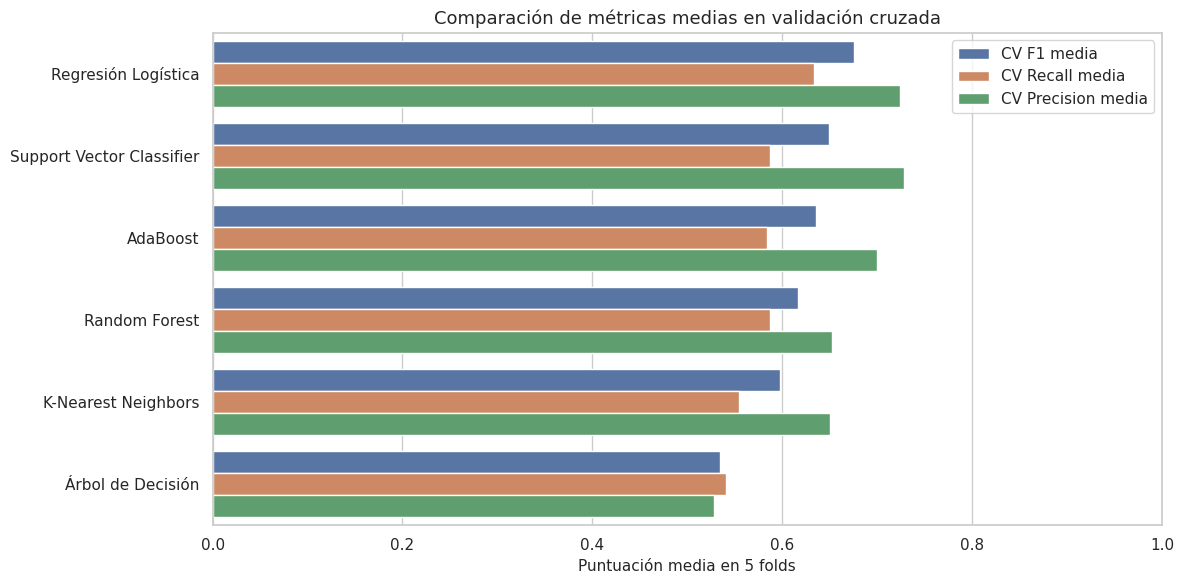

In [30]:
metricas_cv_grafico = resultados_base_df[
    ["Modelo", "CV F1 media", "CV Recall media", "CV Precision media"]
].melt(id_vars="Modelo", var_name="Métrica", value_name="Puntuación")

plt.figure(figsize=(12, 6))
sns.barplot(data=metricas_cv_grafico, x="Puntuación", y="Modelo", hue="Métrica")
plt.xlim(0, 1)
plt.title("Comparación de métricas medias en validación cruzada")
plt.xlabel("Puntuación media en 5 folds")
plt.ylabel("")
plt.legend(title="")
plt.tight_layout()
plt.show()

#### Persistencia de la tabla

Se guarda una copia de las métricas en `notebooks/resultados/informe_4/metricas_modelos_base.csv` para facilitar la integración y el control de versiones.

In [31]:
def localizar_raiz_repositorio():
    """Busca la raíz que contiene bloque_b_python; usa el directorio actual como respaldo."""
    if isinstance(data_source, Path):
        for base in [data_source.parent, *data_source.parents]:
            if (base / "bloque_b_python").is_dir():
                return base

    current_path = Path.cwd().resolve()
    for base in [current_path, *current_path.parents]:
        if (base / "bloque_b_python").is_dir():
            return base

    return current_path

repo_root = localizar_raiz_repositorio()
results_dir = repo_root / "bloque_b_python" / "resultados" / "informe_4"
results_dir.mkdir(parents=True, exist_ok=True)
metrics_path = results_dir / "metricas_modelos_base.csv"
resultados_base_df.to_csv(metrics_path, index=False, encoding="utf-8-sig")
print(f"Tabla guardada en: {metrics_path}")

Tabla guardada en: /mnt/data/final_repo/Proyecto_IA-master/notebooks/resultados/informe_4/metricas_modelos_base.csv


### Interpretación de las familias de modelos

#### Regresión Logística — modelo lineal

Estima una combinación lineal de las variables y la convierte en probabilidad de abandono. Es estable e interpretable, aunque puede quedarse corta ante relaciones muy no lineales.

#### K-Nearest Neighbors — modelo basado en distancia

Clasifica según los vecinos más cercanos. El escalamiento es indispensable. Puede ser sensible al número de vecinos, al ruido y a la dimensionalidad generada por One-Hot Encoding.

#### Support Vector Classifier — modelo de margen

Busca una frontera que maximiza la separación entre clases. El kernel RBF permite relaciones no lineales. Su desempeño depende de `C` y `gamma`, todavía sin optimizar.

#### Árbol de Decisión — modelo basado en reglas

Captura interacciones no lineales y produce reglas interpretables. Sin restricciones puede adaptarse demasiado al entrenamiento.

#### Random Forest — ensamble por bagging

Combina múltiples árboles y suele reducir la varianza de un árbol individual. Es robusto, aunque menos interpretable que un solo árbol.

#### AdaBoost — boosting secuencial

Construye clasificadores débiles sucesivos y concentra el aprendizaje en casos mal clasificados. Puede ser sensible al ruido y a registros inconsistentes.

> La comparación definitiva requerirá analizar balanceo, estabilidad entre folds y ajuste de hiperparámetros. Los resultados del test no se usarán para modificar estas configuraciones base.

### Hallazgos preliminares de los modelos base

#### Modelos más prometedores según validación cruzada

La comparación se ordenó principalmente por **F1 medio de validación cruzada**, porque esta métrica equilibra Precision y Recall para la clase positiva de abandono.

1. **Regresión Logística** obtuvo el mejor resultado general: F1 medio de **0.6755**, Recall medio de **0.6339** y ROC-AUC medio de **0.8199**. Su combinación de rendimiento, estabilidad e interpretabilidad la convierte en la principal línea base para las siguientes etapas.
2. **Support Vector Classifier** alcanzó un F1 medio de **0.6489** y ROC-AUC de **0.7946**. Es un candidato importante porque puede capturar fronteras no lineales, aunque todavía deben ajustarse `C` y `gamma`.
3. **AdaBoost** consiguió un F1 medio de **0.6356** y ROC-AUC de **0.8011**. Además de ser el mejor modelo de boosting de esta etapa, cumple el requisito de evaluar un ensamble secuencial y debe mantenerse como candidato para optimización.
4. **Random Forest** obtuvo un F1 medio de **0.6167**, pero presentó la menor desviación de F1 entre folds (**0.0207**), lo que sugiere un comportamiento relativamente estable. Puede incluirse como candidato secundario en la comparación de balanceo o hiperparámetros.

#### Comportamiento en el conjunto de prueba

Los resultados del test son descriptivos y no se usarán para cambiar parámetros en esta etapa. La Regresión Logística también obtuvo el mayor ROC-AUC del test (**0.7933**) y el mayor F1 entre los modelos evaluados (**0.5854**). Sin embargo, su Recall fue solamente **0.5217**, es decir, detectó poco más de la mitad de los abandonos reales.

Todos los modelos mostraron Recall del test inferior a 0.53. Además, salvo el Árbol de Decisión, predijeron entre 61 y 72 clientes positivos cuando en el conjunto de prueba existían 92 abandonos reales. Este patrón indica una tendencia a favorecer la clase mayoritaria `No`, por lo que la siguiente etapa debe comparar de forma controlada:

- entrenamiento sin balanceo;
- `class_weight="balanced"` en los modelos compatibles;
- SMOTE aplicado exclusivamente dentro de los folds de entrenamiento.

#### Advertencias técnicas

- El **Árbol de Decisión** presentó el rendimiento más bajo: F1 medio de **0.5342** y ROC-AUC medio de **0.6207**. Su configuración sin restricciones probablemente tiene alta varianza y requiere regularización mediante profundidad, hojas mínimas u otros hiperparámetros.
- KNN quedó por debajo de los modelos lineales, de margen y de ensamble. Su resultado puede cambiar al ajustar el número de vecinos y el esquema de ponderación.
- Los resultados del test son menores que los promedios de validación cruzada en varios modelos. Esto puede reflejar un conjunto de prueba más difícil o variabilidad muestral; todavía no constituye por sí solo evidencia concluyente de sobreajuste.
- Se utilizó el mismo preprocesador para todos los modelos por consistencia experimental. `StandardScaler` es importante para Regresión Logística, KNN y SVC, aunque los modelos basados en árboles no lo necesitan estrictamente.
- No se aplicó SMOTE, `class_weight`, ajuste de umbral ni búsqueda de hiperparámetros.

#### Decisión provisional

Para la próxima etapa se priorizarán **Regresión Logística, SVC y AdaBoost** por sus resultados de validación cruzada. Random Forest se conservará como referencia de ensamble estable. La selección definitiva se realizará únicamente después de comparar estrategias de balanceo y ejecutar ajuste de hiperparámetros dentro del conjunto de entrenamiento.

In [32]:
assert len(resultados_base_df) == len(base_models) == 6
assert resultados_base_df["Modelo"].is_unique
assert resultados_base_df.drop(columns="Modelo").notna().all().all()
assert set(modelos_base_ajustados) == set(base_models)
assert metrics_path.exists()
assert len(X_train) == 960 and len(X_test) == 240
assert int((y_train == 1).sum()) == 366
assert int((y_test == 1).sum()) == 92

print("Las verificaciones del modelado base fueron superadas.")
print("No se aplicó SMOTE ni se ejecutó búsqueda de hiperparámetros.")

Las verificaciones del modelado base fueron superadas.
No se aplicó SMOTE ni se ejecutó búsqueda de hiperparámetros.


### Análisis riguroso del desbalance de clases

La variable objetivo presenta un desbalance **moderado**: en el conjunto de entrenamiento existen 594 clientes que permanecen y 366 que abandonan. Por ello, no se asumirá que una técnica de sobremuestreo mejora automáticamente el problema.

Esta sección compara tres estrategias utilizando exclusivamente `X_train` e `y_train`:

1. **Sin balanceo:** conserva la distribución original.
2. **`class_weight="balanced"`:** aumenta el costo de los errores sobre la clase minoritaria sin crear observaciones artificiales.
3. **SMOTE:** genera observaciones sintéticas de la clase minoritaria dentro de cada fold de validación cruzada.

El conjunto de prueba permanece completamente aislado. No se utiliza para escoger la estrategia de balanceo.

In [33]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print("imbalanced-learn disponible. SMOTE se aplicará dentro de cada fold de validación cruzada.")

imbalanced-learn disponible. SMOTE se aplicará dentro de cada fold de validación cruzada.


#### Distribución original del entrenamiento

La distribución se revisa después de la separación `train/test`. Esto evita que cualquier decisión de balanceo utilice información del conjunto de prueba.

,Cantidad,Porcentaje
abandono,,
No abandona (0),594,61.88
Abandona (1),366,38.12


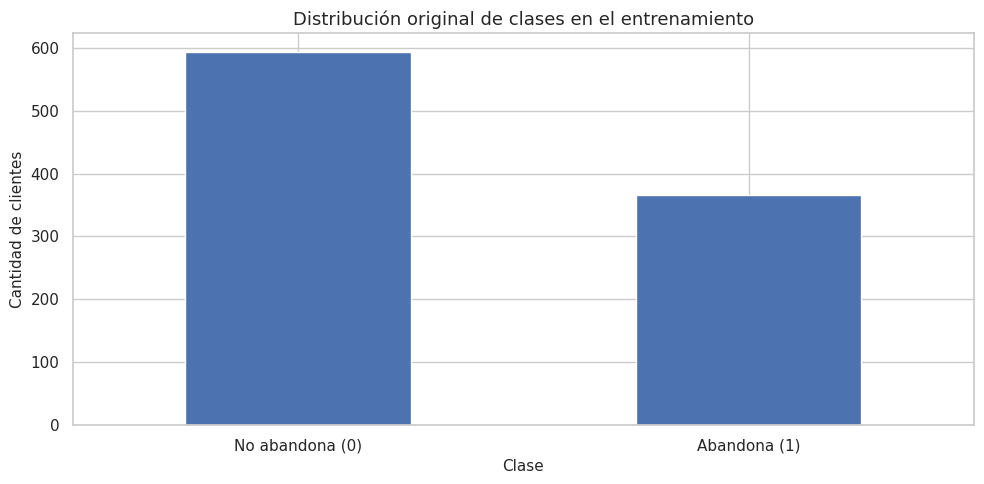

In [34]:
distribucion_train_original = (
    y_train.value_counts()
    .sort_index()
    .rename(index={0: "No abandona (0)", 1: "Abandona (1)"})
    .rename("Cantidad")
    .to_frame()
)
distribucion_train_original["Porcentaje"] = (
    distribucion_train_original["Cantidad"] / len(y_train) * 100
).round(2)

display(distribucion_train_original)

ax = distribucion_train_original["Cantidad"].plot(kind="bar", rot=0)
ax.set_title("Distribución original de clases en el entrenamiento")
ax.set_xlabel("Clase")
ax.set_ylabel("Cantidad de clientes")
plt.tight_layout()
plt.show()

#### Diseño experimental de las estrategias

Se evalúan Regresión Logística, Support Vector Classifier y Random Forest porque representan tres familias distintas y fueron modelos competitivos en la etapa base.

Para cada combinación modelo–estrategia se utiliza `StratifiedKFold` de cinco particiones. El preprocesamiento se vuelve a ajustar dentro de cada fold. En el caso de SMOTE, el orden del pipeline es:

```text
Datos del fold de entrenamiento
        ↓
Imputación + escalamiento + One-Hot Encoding
        ↓
SMOTE solamente sobre ese fold
        ↓
Modelo de clasificación
```

De esta forma, las observaciones sintéticas nunca se generan a partir del fold de validación ni del conjunto de prueba.

In [35]:
balance_models = OrderedDict({
    "Regresión Logística": LogisticRegression(max_iter=2000, random_state=SEED),
    "Support Vector Classifier": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        random_state=SEED,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=SEED,
        n_jobs=1,
    ),
})

balance_scoring = {
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
}


def construir_pipeline_balanceo(estimador, estrategia):
    """Construye un pipeline sin balanceo, con pesos o con SMOTE."""
    modelo = clone(estimador)

    if estrategia == "class_weight='balanced'":
        modelo.set_params(class_weight="balanced")

    if estrategia == "SMOTE":
        return ImbPipeline(
            steps=[
                ("preprocessor", clone(preprocessor)),
                ("smote", SMOTE(random_state=SEED)),
                ("model", modelo),
            ]
        )

    return Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("model", modelo),
        ]
    )


def evaluar_balanceo(nombre_modelo, estimador, estrategia):
    """Evalúa una estrategia exclusivamente mediante CV sobre entrenamiento."""
    pipeline_balanceo = construir_pipeline_balanceo(estimador, estrategia)

    cv_result = cross_validate(
        estimator=pipeline_balanceo,
        X=X_train,
        y=y_train,
        cv=cv_strategy,
        scoring=balance_scoring,
        n_jobs=1,
        return_train_score=False,
        error_score="raise",
    )

    return {
        "Modelo": nombre_modelo,
        "Estrategia": estrategia,
        "CV Precision media": cv_result["test_precision"].mean(),
        "CV Recall media": cv_result["test_recall"].mean(),
        "CV F1 media": cv_result["test_f1"].mean(),
        "CV F1 desviación": cv_result["test_f1"].std(),
        "CV ROC-AUC media": cv_result["test_roc_auc"].mean(),
        "Tiempo CV total (s)": cv_result["fit_time"].sum(),
    }

print("Modelos y estrategias configurados correctamente.")

Modelos y estrategias configurados correctamente.


In [36]:
estrategias_balanceo = [
    "Sin balanceo",
    "class_weight='balanced'",
    "SMOTE",
]

resultados_balanceo = []

for nombre_modelo, estimador in balance_models.items():
    for estrategia in estrategias_balanceo:
        print(f"Evaluando {nombre_modelo} — {estrategia}...")
        resultados_balanceo.append(
            evaluar_balanceo(nombre_modelo, estimador, estrategia)
        )

resultados_balanceo_df = pd.DataFrame(resultados_balanceo)

baseline_f1 = (
    resultados_balanceo_df[
        resultados_balanceo_df["Estrategia"] == "Sin balanceo"
    ]
    .set_index("Modelo")["CV F1 media"]
)
baseline_recall = (
    resultados_balanceo_df[
        resultados_balanceo_df["Estrategia"] == "Sin balanceo"
    ]
    .set_index("Modelo")["CV Recall media"]
)

resultados_balanceo_df["Variación F1 vs base"] = (
    resultados_balanceo_df["CV F1 media"]
    - resultados_balanceo_df["Modelo"].map(baseline_f1)
)
resultados_balanceo_df["Variación Recall vs base"] = (
    resultados_balanceo_df["CV Recall media"]
    - resultados_balanceo_df["Modelo"].map(baseline_recall)
)

resultados_balanceo_df = (
    resultados_balanceo_df
    .sort_values(
        by=["CV F1 media", "CV Recall media", "CV ROC-AUC media"],
        ascending=False,
    )
    .reset_index(drop=True)
)

print("Comparación de estrategias completada.")

Evaluando Regresión Logística — Sin balanceo...


Evaluando Regresión Logística — class_weight='balanced'...


Evaluando Regresión Logística — SMOTE...


Evaluando Support Vector Classifier — Sin balanceo...
Evaluando Support Vector Classifier — class_weight='balanced'...


Evaluando Support Vector Classifier — SMOTE...
Evaluando Random Forest — Sin balanceo...


Evaluando Random Forest — class_weight='balanced'...


Evaluando Random Forest — SMOTE...


Comparación de estrategias completada.


In [37]:
columnas_balanceo = [
    "Modelo",
    "Estrategia",
    "CV Precision media",
    "CV Recall media",
    "CV F1 media",
    "CV F1 desviación",
    "CV ROC-AUC media",
    "Variación F1 vs base",
    "Variación Recall vs base",
    "Tiempo CV total (s)",
]

tabla_balanceo = resultados_balanceo_df[columnas_balanceo].copy()
columnas_numericas_balanceo = tabla_balanceo.select_dtypes(include="number").columns
tabla_balanceo[columnas_numericas_balanceo] = (
    tabla_balanceo[columnas_numericas_balanceo].round(4)
)

tabla_balanceo

,Modelo,Estrategia,CV Precision media,CV Recall media,CV F1 media,CV F1 desviación,CV ROC-AUC media,Variación F1 vs base,Variación Recall vs base,Tiempo CV total (s)
0,Regresión Logística,SMOTE,0.6472,0.7514,0.6949,0.0250,0.8197,0.0193,0.1175,0.1156
1,Regresión Logística,class_weight='balanced',0.6376,0.7623,0.6941,0.0224,0.8197,0.0186,0.1285,0.2278
2,Support Vector Classifier,class_weight='balanced',0.6380,0.7433,0.6859,0.0286,0.7967,0.0370,0.1558,0.0689
3,Support Vector Classifier,SMOTE,0.6450,0.7296,0.6844,0.0286,0.7969,0.0355,0.1421,0.0953
4,Regresión Logística,Sin balanceo,0.7240,0.6339,0.6755,0.0410,0.8199,0.0000,0.0000,0.0429
5,Support Vector Classifier,Sin balanceo,0.7283,0.5875,0.6489,0.0274,0.7946,0.0000,0.0000,0.0626
6,Random Forest,SMOTE,0.6444,0.6393,0.6403,0.0213,0.7789,0.0235,0.0519,0.7462
7,Random Forest,Sin balanceo,0.6520,0.5874,0.6167,0.0207,0.7787,0.0000,0.0000,0.6551
8,Random Forest,class_weight='balanced',0.6457,0.5791,0.6095,0.0247,0.7819,-0.0072,-0.0083,0.6692


In [38]:
resumen_estrategias = (
    resultados_balanceo_df
    .groupby("Estrategia", as_index=False)[
        [
            "CV Precision media",
            "CV Recall media",
            "CV F1 media",
            "CV ROC-AUC media",
        ]
    ]
    .mean()
    .sort_values("CV F1 media", ascending=False)
    .reset_index(drop=True)
)

resumen_estrategias_redondeado = resumen_estrategias.copy()
metricas_resumen = resumen_estrategias_redondeado.select_dtypes(include="number").columns
resumen_estrategias_redondeado[metricas_resumen] = (
    resumen_estrategias_redondeado[metricas_resumen].round(4)
)

print("Promedio de cada estrategia entre los tres modelos:")
display(resumen_estrategias_redondeado)

Promedio de cada estrategia entre los tres modelos:


,Estrategia,CV Precision media,CV Recall media,CV F1 media,CV ROC-AUC media
0,SMOTE,0.6455,0.7068,0.6732,0.7985
1,class_weight='balanced',0.6404,0.6949,0.6632,0.7994
2,Sin balanceo,0.7014,0.6029,0.6471,0.7977


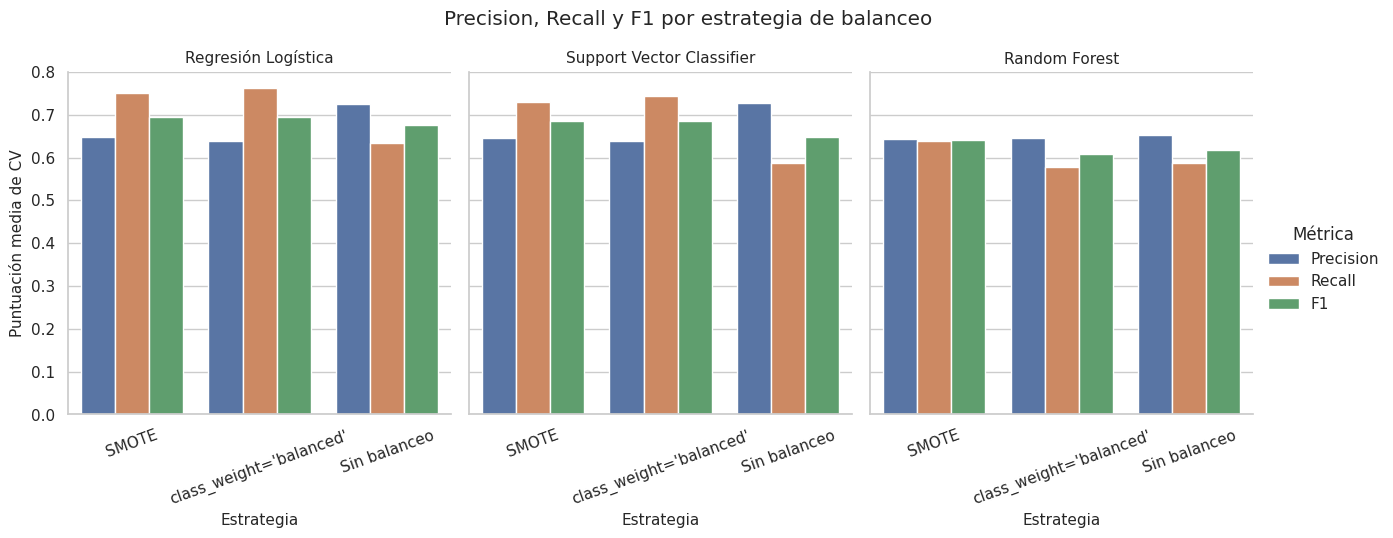

In [39]:
metricas_balanceo_plot = resultados_balanceo_df.melt(
    id_vars=["Modelo", "Estrategia"],
    value_vars=["CV Precision media", "CV Recall media", "CV F1 media"],
    var_name="Métrica",
    value_name="Puntuación",
)

metricas_balanceo_plot["Métrica"] = metricas_balanceo_plot["Métrica"].str.replace(
    "CV ", "", regex=False
).str.replace(" media", "", regex=False)

g = sns.catplot(
    data=metricas_balanceo_plot,
    x="Estrategia",
    y="Puntuación",
    hue="Métrica",
    col="Modelo",
    kind="bar",
    height=4.5,
    aspect=0.95,
    sharey=True,
)
g.set_axis_labels("Estrategia", "Puntuación media de CV")
g.set_titles("{col_name}")
g.set_xticklabels(rotation=20)
g.fig.suptitle("Precision, Recall y F1 por estrategia de balanceo", y=1.05)
plt.show()

#### Distribución generada por SMOTE

La siguiente celda realiza una demostración independiente usando únicamente el conjunto de entrenamiento. Este remuestreo sirve para inspeccionar la distribución resultante; **no se reutiliza para entrenar ni validar los modelos anteriores**. Durante la validación cruzada, cada pipeline genera sus propias muestras sintéticas dentro de cada fold.

,Clase,Original,Después de SMOTE
0,No abandona (0),594,594
1,Abandona (1),366,594


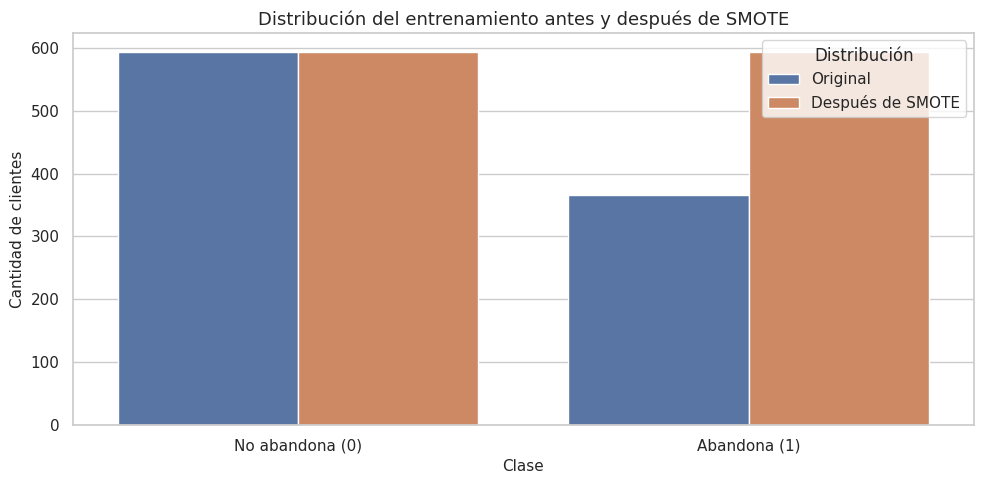

Observaciones sintéticas creadas: 228
Observaciones sintéticas con algún valor One-Hot fraccionario: 1


In [40]:
preprocessor_smote_demo = clone(preprocessor)
X_train_demo = preprocessor_smote_demo.fit_transform(X_train, y_train)

smote_demo = SMOTE(random_state=SEED)
X_train_smote_demo, y_train_smote_demo = smote_demo.fit_resample(
    X_train_demo,
    y_train,
)

distribucion_smote = pd.DataFrame({
    "Clase": ["No abandona (0)", "Abandona (1)"],
    "Original": [int((y_train == 0).sum()), int((y_train == 1).sum())],
    "Después de SMOTE": [
        int((y_train_smote_demo == 0).sum()),
        int((y_train_smote_demo == 1).sum()),
    ],
})

display(distribucion_smote)

smote_plot = distribucion_smote.melt(
    id_vars="Clase",
    var_name="Distribución",
    value_name="Cantidad",
)

sns.barplot(
    data=smote_plot,
    x="Clase",
    y="Cantidad",
    hue="Distribución",
)
plt.title("Distribución del entrenamiento antes y después de SMOTE")
plt.xlabel("Clase")
plt.ylabel("Cantidad de clientes")
plt.tight_layout()
plt.show()

# Auditoría de las columnas One-Hot en las observaciones sintéticas.
feature_names_smote = preprocessor_smote_demo.get_feature_names_out()
indices_categoricos = [
    idx
    for idx, nombre in enumerate(feature_names_smote)
    if nombre.startswith("plan_contratado_")
]

filas_sinteticas = X_train_smote_demo[len(X_train):]
valores_categoricos_sinteticos = filas_sinteticas[:, indices_categoricos]
mascara_fraccionaria = np.any(
    (~np.isclose(valores_categoricos_sinteticos, 0))
    & (~np.isclose(valores_categoricos_sinteticos, 1)),
    axis=1,
)

cantidad_sintetica = len(filas_sinteticas)
cantidad_fraccionaria = int(mascara_fraccionaria.sum())

print(f"Observaciones sintéticas creadas: {cantidad_sintetica}")
print(
    "Observaciones sintéticas con algún valor One-Hot fraccionario: "
    f"{cantidad_fraccionaria}"
)

#### Interpretación de los resultados

Los resultados de validación cruzada muestran que el balanceo aumenta la capacidad de detectar clientes que abandonan:

- **Regresión Logística + SMOTE:** F1 = **0.6949**, Recall = **0.7514** y Precision = **0.6472**.
- **Regresión Logística + `class_weight`:** F1 = **0.6941**, Recall = **0.7623** y Precision = **0.6376**.
- **SVC + `class_weight`:** F1 = **0.6859** y Recall = **0.7433**.
- **SVC + SMOTE:** F1 = **0.6844** y Recall = **0.7296**.
- **Random Forest + SMOTE:** F1 = **0.6403**, superior al F1 sin balanceo de **0.6167**.

En promedio entre los tres algoritmos, SMOTE obtuvo el mayor F1 (**0.6732**) y el mayor Recall (**0.7068**). La estrategia sin balanceo alcanzó mayor Precision promedio (**0.7014**), pero su Recall fue considerablemente menor (**0.6029**). Esto significa que el balanceo detecta más abandonos reales a cambio de generar más alertas falsas.

La Regresión Logística sin balanceo tenía un Recall de **0.6339**. Con SMOTE aumentó aproximadamente **11.75 puntos porcentuales**, mientras que con pesos de clase aumentó aproximadamente **12.85 puntos porcentuales**. La diferencia de F1 entre SMOTE y `class_weight` en este modelo es mínima, por lo que ambas estrategias son técnicamente competitivas.

#### Costo de los errores para NovaConecta

**Falso negativo:** el modelo predice que un cliente permanecerá, pero el cliente realmente abandona. Es el error de mayor impacto, porque NovaConecta no ejecutaría ninguna campaña de retención y perdería ingresos futuros.

**Falso positivo:** el modelo predice abandono, pero el cliente permanece. La empresa podría ofrecer un descuento o contactar innecesariamente al cliente. Existe un costo comercial, pero normalmente es menor que perder por completo a un cliente valioso.

Por esta razón, NovaConecta debe favorecer una estrategia que aumente el Recall sin llevar la Precision a niveles demasiado bajos. El F1 se mantiene como métrica principal porque resume ambos objetivos.

#### Decisión para el ajuste de hiperparámetros

Se utilizará **SMOTE como estrategia principal** en la siguiente etapa porque:

1. Obtuvo el mayor F1 promedio entre los tres modelos evaluados.
2. Alcanzó el mayor Recall promedio, reduciendo el riesgo de no detectar clientes que abandonan.
3. Mejoró el F1 de Regresión Logística y Random Forest respecto a sus versiones sin balanceo.
4. Se aplica correctamente dentro del pipeline y dentro de cada fold, por lo que no contamina la validación.

`class_weight="balanced"` se conservará como referencia secundaria, especialmente para Regresión Logística y SVC, donde produjo resultados muy cercanos y evita crear datos artificiales.

Existe una limitación técnica: SMOTE se aplica después de One-Hot Encoding y podría interpolar valores fraccionarios en variables categóricas. En esta ejecución se generaron 228 observaciones sintéticas y solo una presentó algún valor One-Hot fraccionario. El efecto fue mínimo, pero debe documentarse. Una extensión futura podría evaluar `SMOTENC` para tratar categorías de forma explícita.

In [41]:
balance_metrics_path = results_dir / "metricas_balanceo.csv"
resultados_balanceo_df.to_csv(
    balance_metrics_path,
    index=False,
    encoding="utf-8-sig",
)

assert set(resultados_balanceo_df["Modelo"]) == set(balance_models)
assert set(resultados_balanceo_df["Estrategia"]) == set(estrategias_balanceo)
assert len(resultados_balanceo_df) == 9
assert resultados_balanceo_df[
    [
        "CV Precision media",
        "CV Recall media",
        "CV F1 media",
        "CV ROC-AUC media",
    ]
].notna().all().all()
assert len(X_train) == 960 and len(X_test) == 240
assert int((y_test == 1).sum()) == 92
assert int((y_train_smote_demo == 0).sum()) == 594
assert int((y_train_smote_demo == 1).sum()) == 594
assert balance_metrics_path.exists()

print(f"Tabla de balanceo guardada en: {balance_metrics_path}")
print("Las nueve comparaciones utilizaron exclusivamente X_train e y_train.")
print("El conjunto de prueba no fue remuestreado ni utilizado para seleccionar la estrategia.")

Tabla de balanceo guardada en: /mnt/data/final_repo/Proyecto_IA-master/notebooks/resultados/informe_4/metricas_balanceo.csv
Las nueve comparaciones utilizaron exclusivamente X_train e y_train.
El conjunto de prueba no fue remuestreado ni utilizado para seleccionar la estrategia.


### Ajuste de hiperparámetros

En esta etapa se optimizan tres candidatos seleccionados **exclusivamente a partir de la validación cruzada del conjunto de entrenamiento**:

1. **Regresión Logística**, por obtener el mejor F1 en la comparación con SMOTE y ofrecer alta interpretabilidad.
2. **Support Vector Classifier**, por su desempeño competitivo en F1, Recall y ROC-AUC.
3. **Random Forest**, porque es un modelo de ensamble, mejoró con SMOTE y permite representar relaciones no lineales.

Aunque AdaBoost tuvo un resultado base competitivo, Random Forest fue incluido porque sí fue evaluado rigurosamente durante el análisis de balanceo y satisface el requisito de incorporar al menos un modelo de ensamble.

Todos los ajustes se realizan mediante pipelines completos con el orden:

> preprocesamiento → SMOTE → modelo

El conjunto de prueba se conserva aislado durante toda la búsqueda.

#### Estrategia de búsqueda

Se utilizará `GridSearchCV` con:

- `StratifiedKFold` de cinco particiones.
- F1 como métrica principal de optimización (`refit="f1"`).
- Accuracy, Precision, Recall y ROC-AUC como métricas complementarias.
- Espacios de búsqueda pequeños y técnicamente razonables para evitar un costo computacional innecesario.
- `n_jobs=1` para mantener estabilidad y reproducibilidad en distintos equipos.

La búsqueda se ajusta únicamente con `X_train` e `y_train`.

In [42]:
import json
from joblib import dump
from sklearn.model_selection import GridSearchCV

print("Librerías para ajuste y persistencia importadas correctamente.")

Librerías para ajuste y persistencia importadas correctamente.


In [43]:
tuning_candidates = OrderedDict({
    "Regresión Logística": {
        "estimator": LogisticRegression(
            max_iter=3000,
            random_state=SEED,
        ),
        "param_grid": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__solver": ["liblinear", "lbfgs"],
        },
    },
    "Support Vector Classifier": {
        "estimator": SVC(
            random_state=SEED,
        ),
        "param_grid": {
            "model__C": [0.1, 1, 10, 30],
            "model__gamma": ["scale", 0.01, 0.1],
            "model__kernel": ["rbf"],
        },
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(
            random_state=SEED,
            n_jobs=1,
        ),
        "param_grid": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [5, 10],
            "model__min_samples_leaf": [2],
            "model__max_features": ["sqrt"],
        },
    },
})

search_sizes = {}
for model_name, config in tuning_candidates.items():
    combinations = int(np.prod([len(values) for values in config["param_grid"].values()]))
    search_sizes[model_name] = combinations

search_summary = pd.DataFrame({
    "Modelo": list(search_sizes.keys()),
    "Combinaciones": list(search_sizes.values()),
    "Ajustes con 5 folds": [value * 5 for value in search_sizes.values()],
})

search_summary

,Modelo,Combinaciones,Ajustes con 5 folds
0,Regresión Logística,8,40
1,Support Vector Classifier,12,60
2,Random Forest,4,20


Los espacios definidos evalúan 24 combinaciones en total, equivalentes a 120 ajustes considerando los cinco folds. Esta cantidad es suficiente para explorar parámetros importantes sin convertir la búsqueda en un proceso excesivo.

In [44]:
def construir_pipeline_smote(estimador):
    """Construye un pipeline completo para optimización sin contaminar el test."""
    return ImbPipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("smote", SMOTE(random_state=SEED)),
            ("model", clone(estimador)),
        ]
    )


def extraer_metricas_mejor_busqueda(nombre_modelo, search, elapsed_seconds):
    """Extrae métricas de CV y evalúa una sola vez el mejor estimador en test."""
    best_index = search.best_index_
    cv_results = search.cv_results_
    best_estimator = search.best_estimator_

    y_pred_test = best_estimator.predict(X_test)
    y_score_test = obtener_puntaje_continuo(best_estimator, X_test)

    return {
        "Modelo": nombre_modelo,
        "Mejores parámetros": search.best_params_,
        "CV Accuracy media": cv_results["mean_test_accuracy"][best_index],
        "CV Precision media": cv_results["mean_test_precision"][best_index],
        "CV Recall media": cv_results["mean_test_recall"][best_index],
        "CV F1 media": cv_results["mean_test_f1"][best_index],
        "CV F1 desviación": cv_results["std_test_f1"][best_index],
        "CV ROC-AUC media": cv_results["mean_test_roc_auc"][best_index],
        "Train F1 media": cv_results["mean_train_f1"][best_index],
        "Brecha Train-CV F1": (
            cv_results["mean_train_f1"][best_index]
            - cv_results["mean_test_f1"][best_index]
        ),
        "Tiempo búsqueda (s)": elapsed_seconds,
        "Test Accuracy": accuracy_score(y_test, y_pred_test),
        "Test Precision": precision_score(y_test, y_pred_test, zero_division=0),
        "Test Recall": recall_score(y_test, y_pred_test, zero_division=0),
        "Test F1": f1_score(y_test, y_pred_test, zero_division=0),
        "Test ROC-AUC": (
            roc_auc_score(y_test, y_score_test)
            if y_score_test is not None
            else np.nan
        ),
    }

print("Funciones de optimización configuradas correctamente.")

Funciones de optimización configuradas correctamente.


In [45]:
import gc

# Libera objetos ajustados que ya no son necesarios para reducir el consumo de memoria.
if "modelos_base_ajustados" in globals():
    modelos_base_ajustados.clear()
plt.close("all")
gc.collect()

optimized_searches = {}
optimized_results = []
test_evaluations = 0

for model_name, config in tuning_candidates.items():
    print(f"Ajustando {model_name}...")

    full_pipeline = construir_pipeline_smote(config["estimator"])

    grid_search = GridSearchCV(
        estimator=full_pipeline,
        param_grid=config["param_grid"],
        scoring=scoring,
        refit="f1",
        cv=cv_strategy,
        n_jobs=1,
        return_train_score=True,
        error_score="raise",
    )

    start_time = perf_counter()
    grid_search.fit(X_train, y_train)
    elapsed = perf_counter() - start_time

    optimized_searches[model_name] = grid_search
    optimized_results.append(
        extraer_metricas_mejor_busqueda(model_name, grid_search, elapsed)
    )
    test_evaluations += 1

    print(
        f"  Mejor F1 CV: {grid_search.best_score_:.4f} | "
        f"Tiempo: {elapsed:.2f} s"
    )

optimized_results_df = (
    pd.DataFrame(optimized_results)
    .sort_values(
        by=["CV F1 media", "CV Recall media", "CV ROC-AUC media"],
        ascending=False,
    )
    .reset_index(drop=True)
)

print("Búsquedas completadas.")

Ajustando Regresión Logística...


  Mejor F1 CV: 0.6974 | Tiempo: 2.24 s
Ajustando Support Vector Classifier...


  Mejor F1 CV: 0.7006 | Tiempo: 4.29 s
Ajustando Random Forest...


  Mejor F1 CV: 0.6761 | Tiempo: 5.26 s
Búsquedas completadas.


#### Mejores parámetros y resultados de validación cruzada

La siguiente tabla presenta los parámetros seleccionados por F1 y las métricas obtenidas exclusivamente durante la validación cruzada del entrenamiento.

In [46]:
cv_columns_optimized = [
    "Modelo",
    "Mejores parámetros",
    "CV Accuracy media",
    "CV Precision media",
    "CV Recall media",
    "CV F1 media",
    "CV F1 desviación",
    "CV ROC-AUC media",
    "Train F1 media",
    "Brecha Train-CV F1",
    "Tiempo búsqueda (s)",
]

optimized_cv_table = optimized_results_df[cv_columns_optimized].copy()
optimized_numeric_columns = optimized_cv_table.select_dtypes(include="number").columns
optimized_cv_table[optimized_numeric_columns] = optimized_cv_table[optimized_numeric_columns].round(4)
optimized_cv_table

,Modelo,Mejores parámetros,CV Accuracy media,CV Precision media,CV Recall media,CV F1 media,CV F1 desviación,CV ROC-AUC media,Train F1 media,Brecha Train-CV F1,Tiempo búsqueda (s)
0,Support Vector Classifier,"{'model__C': 1, 'model__gamma': 0.01, 'model__...",0.7500,0.6477,0.7650,0.7006,0.0247,0.8204,0.7072,0.0065,4.2941
1,Regresión Logística,"{'model__C': 10, 'model__solver': 'liblinear'}",0.7500,0.6496,0.7541,0.6974,0.0277,0.8193,0.6979,0.0005,2.2387
2,Random Forest,"{'model__max_depth': 5, 'model__max_features':...",0.7396,0.6431,0.7131,0.6761,0.0255,0.7998,0.7614,0.0852,5.2613


#### Comparación con las versiones base

La comparación principal se realiza contra la versión con SMOTE y parámetros por defecto, porque la estrategia seleccionada en la etapa anterior fue SMOTE. También se conserva como referencia el F1 del modelo originalmente entrenado sin balanceo.

In [47]:
base_unbalanced_lookup = (
    resultados_base_df
    .set_index("Modelo")["CV F1 media"]
)

base_smote_lookup = (
    resultados_balanceo_df[
        resultados_balanceo_df["Estrategia"] == "SMOTE"
    ]
    .set_index("Modelo")["CV F1 media"]
)

comparison_rows = []
for _, row in optimized_results_df.iterrows():
    model_name = row["Modelo"]
    base_unbalanced_f1 = float(base_unbalanced_lookup.loc[model_name])
    base_smote_f1 = float(base_smote_lookup.loc[model_name])
    optimized_f1 = float(row["CV F1 media"])

    comparison_rows.append({
        "Modelo": model_name,
        "F1 base sin balanceo": base_unbalanced_f1,
        "F1 base con SMOTE": base_smote_f1,
        "F1 optimizado con SMOTE": optimized_f1,
        "Mejora vs base sin balanceo": optimized_f1 - base_unbalanced_f1,
        "Mejora vs base SMOTE": optimized_f1 - base_smote_f1,
    })

optimization_comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values("F1 optimizado con SMOTE", ascending=False)
    .reset_index(drop=True)
)

optimization_comparison_df.round(4)

,Modelo,F1 base sin balanceo,F1 base con SMOTE,F1 optimizado con SMOTE,Mejora vs base sin balanceo,Mejora vs base SMOTE
0,Support Vector Classifier,0.6489,0.6844,0.7006,0.0517,0.0162
1,Regresión Logística,0.6755,0.6949,0.6974,0.0219,0.0026
2,Random Forest,0.6167,0.6403,0.6761,0.0594,0.0359


#### Evaluación final única sobre el conjunto de prueba

Después de completar todas las búsquedas con entrenamiento, cada mejor pipeline se evalúa una única vez sobre las 240 observaciones de prueba. Estos resultados permiten estimar la generalización, pero **no se utilizan para volver a modificar parámetros ni cambiar la búsqueda**.

In [48]:
test_columns_optimized = [
    "Modelo",
    "Test Accuracy",
    "Test Precision",
    "Test Recall",
    "Test F1",
    "Test ROC-AUC",
]

optimized_test_table = optimized_results_df[test_columns_optimized].copy()
optimized_test_numeric = optimized_test_table.select_dtypes(include="number").columns
optimized_test_table[optimized_test_numeric] = optimized_test_table[optimized_test_numeric].round(4)
optimized_test_table

,Modelo,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Support Vector Classifier,0.7125,0.6055,0.7174,0.6567,0.7872
1,Regresión Logística,0.7292,0.6286,0.7174,0.6701,0.7927
2,Random Forest,0.6917,0.5900,0.6413,0.6146,0.7573


#### Señales de sobreajuste

La brecha entre el F1 promedio de entrenamiento y el F1 de validación cruzada sirve como indicador aproximado:

- Una brecha pequeña sugiere un comportamiento estable.
- Una brecha elevada puede indicar que el modelo está aprendiendo detalles específicos de los folds de entrenamiento.

Random Forest presenta la mayor brecha de los tres candidatos, por lo que debe interpretarse con mayor cautela. Regresión Logística y SVC muestran diferencias reducidas entre entrenamiento y validación.

In [49]:
overfitting_table = optimized_results_df[
    [
        "Modelo",
        "Train F1 media",
        "CV F1 media",
        "CV F1 desviación",
        "Brecha Train-CV F1",
    ]
].copy()

overfitting_numeric = overfitting_table.select_dtypes(include="number").columns
overfitting_table[overfitting_numeric] = overfitting_table[overfitting_numeric].round(4)
overfitting_table

,Modelo,Train F1 media,CV F1 media,CV F1 desviación,Brecha Train-CV F1
0,Support Vector Classifier,0.7072,0.7006,0.0247,0.0065
1,Regresión Logística,0.6979,0.6974,0.0277,0.0005
2,Random Forest,0.7614,0.6761,0.0255,0.0852


#### Selección del modelo

El **Support Vector Classifier optimizado** se selecciona como modelo ganador de esta etapa porque:

- Obtuvo el mayor F1 de validación cruzada: aproximadamente **0.7006**.
- Alcanzó el mayor Recall medio: aproximadamente **0.7650**, importante para reducir falsos negativos.
- Presentó el mayor ROC-AUC medio: aproximadamente **0.8204**.
- Su desviación de F1 fue baja y la brecha entre entrenamiento y validación fue reducida.
- Superó claramente a su versión base con SMOTE.

La Regresión Logística quedó extremadamente cerca y es la alternativa más interpretable. Random Forest mejoró con la optimización, pero presentó una brecha Train-CV mayor, señal de un riesgo de sobreajuste superior.

La selección se basa en validación cruzada. La evaluación del test se reporta únicamente como comprobación final de generalización.

In [50]:
selected_model_name = optimized_results_df.iloc[0]["Modelo"]
selected_search = optimized_searches[selected_model_name]
selected_pipeline = selected_search.best_estimator_

print(f"Modelo seleccionado por validación cruzada: {selected_model_name}")
print(f"Mejor F1 CV: {selected_search.best_score_:.4f}")
print(f"Mejores parámetros: {selected_search.best_params_}")

Modelo seleccionado por validación cruzada: Support Vector Classifier
Mejor F1 CV: 0.7006
Mejores parámetros: {'model__C': 1, 'model__gamma': 0.01, 'model__kernel': 'rbf'}


#### Persistencia de resultados

Se guardan las métricas definitivas, los mejores parámetros y el pipeline ganador completo. El archivo `.joblib` incorpora el preprocesamiento, SMOTE y el modelo, por lo que puede recibir directamente registros con las variables originales.

In [51]:
final_metrics_path = results_dir / "metricas_modelos_finales.csv"
best_params_path = results_dir / "mejores_parametros.json"
best_model_path = results_dir / "mejor_modelo_clasificacion.joblib"

final_metrics_to_save = optimized_results_df.copy()
final_metrics_to_save["Mejores parámetros"] = final_metrics_to_save[
    "Mejores parámetros"
].apply(json.dumps, ensure_ascii=False)
final_metrics_to_save.to_csv(
    final_metrics_path,
    index=False,
    encoding="utf-8-sig",
)

best_params_serializable = {
    model_name: {
        key: (value.item() if isinstance(value, np.generic) else value)
        for key, value in search.best_params_.items()
    }
    for model_name, search in optimized_searches.items()
}

with open(best_params_path, "w", encoding="utf-8") as file:
    json.dump(best_params_serializable, file, ensure_ascii=False, indent=2)

dump(selected_pipeline, best_model_path)

print(f"Métricas finales: {final_metrics_path}")
print(f"Mejores parámetros: {best_params_path}")
print(f"Modelo seleccionado: {best_model_path}")

Métricas finales: /mnt/data/final_repo/Proyecto_IA-master/notebooks/resultados/informe_4/metricas_modelos_finales.csv
Mejores parámetros: /mnt/data/final_repo/Proyecto_IA-master/notebooks/resultados/informe_4/mejores_parametros.json
Modelo seleccionado: /mnt/data/final_repo/Proyecto_IA-master/notebooks/resultados/informe_4/mejor_modelo_clasificacion.joblib


#### Verificaciones de la etapa

Las siguientes aserciones verifican que:

- Se optimizaron exactamente tres modelos.
- Todas las búsquedas utilizaron cinco folds.
- Los pipelines contienen preprocesamiento, SMOTE y modelo.
- El test se evaluó una sola vez por modelo después de la búsqueda.
- Los archivos finales fueron creados.
- El modelo seleccionado coincide con el mayor F1 de validación cruzada.

In [52]:
assert len(optimized_searches) == 3
assert set(optimized_searches) == set(tuning_candidates)
assert test_evaluations == 3
assert len(optimized_results_df) == 3
assert optimized_results_df.drop(columns=["Modelo", "Mejores parámetros"]).notna().all().all()
assert selected_model_name == optimized_results_df.iloc[0]["Modelo"]
assert selected_model_name == "Support Vector Classifier"

for model_name, search in optimized_searches.items():
    assert search.cv.get_n_splits() == 5
    assert list(search.best_estimator_.named_steps) == [
        "preprocessor",
        "smote",
        "model",
    ]

assert len(X_train) == 960 and len(X_test) == 240
assert int((y_test == 1).sum()) == 92
assert final_metrics_path.exists()
assert best_params_path.exists()
assert best_model_path.exists()

print("Todas las verificaciones del ajuste de hiperparámetros fueron superadas.")
print("GridSearchCV utilizó exclusivamente X_train e y_train.")
print("El conjunto de prueba se evaluó una sola vez por modelo después de la búsqueda.")

Todas las verificaciones del ajuste de hiperparámetros fueron superadas.
GridSearchCV utilizó exclusivamente X_train e y_train.
El conjunto de prueba se evaluó una sola vez por modelo después de la búsqueda.


#### Conclusión de la optimización

El ajuste de hiperparámetros mejoró los tres candidatos frente a sus configuraciones base con SMOTE. SVC produjo el mayor F1 medio de validación y fue seleccionado como modelo principal. Regresión Logística se mantiene como alternativa altamente competitiva por su interpretabilidad, mientras que Random Forest presentó una señal moderada de sobreajuste. La siguiente sección realiza la evaluación final, la interpretación de errores y la auditoría de calidad.

## Evaluación de resultados y visualizaciones

### Evaluación final del modelo seleccionado

El modelo ganador se eligió **antes de revisar esta evaluación final**, utilizando exclusivamente el F1 promedio de validación cruzada sobre el conjunto de entrenamiento. El modelo seleccionado fue **Support Vector Classifier con SMOTE**, kernel RBF, `C=1` y `gamma=0.01`.

En esta sección se calculan la matriz de confusión, el reporte de clasificación y las curvas de evaluación sobre las 240 observaciones del conjunto de prueba.

In [53]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_curve,
)

# El pipeline seleccionado ya fue reajustado por GridSearchCV con todo X_train.
y_pred_final = selected_pipeline.predict(X_test)
y_score_final = obtener_puntaje_continuo(selected_pipeline, X_test)

cm_final = confusion_matrix(y_test, y_pred_final, labels=[0, 1])
tn, fp, fn, tp = cm_final.ravel()

metricas_ganador = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Valor": [
        accuracy_score(y_test, y_pred_final),
        precision_score(y_test, y_pred_final, zero_division=0),
        recall_score(y_test, y_pred_final, zero_division=0),
        f1_score(y_test, y_pred_final, zero_division=0),
        roc_auc_score(y_test, y_score_final),
    ],
})

reporte_final_dict = classification_report(
    y_test,
    y_pred_final,
    labels=[0, 1],
    target_names=["No abandona", "Abandona"],
    output_dict=True,
    zero_division=0,
)
reporte_final_df = pd.DataFrame(reporte_final_dict).T

metricas_ganador.round(4)

,Métrica,Valor
0,Accuracy,0.7125
1,Precision,0.6055
2,Recall,0.7174
3,F1-Score,0.6567
4,ROC-AUC,0.7872


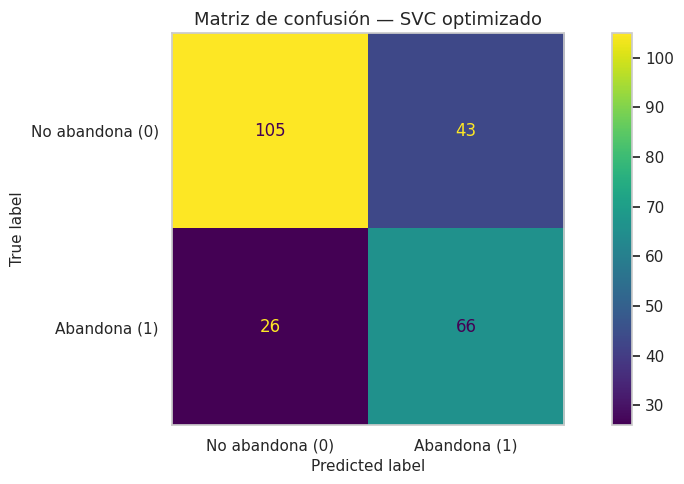

Verdaderos negativos (TN): 105
Falsos positivos (FP): 43
Falsos negativos (FN): 26
Verdaderos positivos (TP): 66


In [54]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["No abandona (0)", "Abandona (1)"],
)
disp.plot(values_format="d")
plt.title("Matriz de confusión — SVC optimizado")
plt.grid(False)
plt.tight_layout()
plt.show()

print(f"Verdaderos negativos (TN): {tn}")
print(f"Falsos positivos (FP): {fp}")
print(f"Falsos negativos (FN): {fn}")
print(f"Verdaderos positivos (TP): {tp}")

#### Interpretación de la matriz de confusión

La matriz final contiene:

- **105 verdaderos negativos:** clientes que permanecieron y fueron clasificados correctamente como no abandono.
- **43 falsos positivos:** clientes que permanecieron, pero fueron señalados como posibles abandonos. Pueden provocar contactos o incentivos innecesarios.
- **26 falsos negativos:** clientes que abandonaron, pero el modelo no los detectó. Representan el error empresarial más delicado.
- **66 verdaderos positivos:** clientes que realmente abandonaron y fueron identificados correctamente.

El modelo detectó **66 de los 92 abandonos reales**, equivalente a un Recall de **0.7174**. Por otro lado, 26 abandonos reales no fueron identificados. De los 109 clientes señalados como riesgosos, 66 realmente abandonaron, lo que produce una Precision de **0.6055**.

In [55]:
print("Classification report del modelo ganador:\n")
print(classification_report(
    y_test,
    y_pred_final,
    labels=[0, 1],
    target_names=["No abandona", "Abandona"],
    digits=4,
    zero_division=0,
))

display(reporte_final_df.round(4))

Classification report del modelo ganador:

              precision    recall  f1-score   support

 No abandona     0.8015    0.7095    0.7527       148
    Abandona     0.6055    0.7174    0.6567        92

    accuracy                         0.7125       240
   macro avg     0.7035    0.7134    0.7047       240
weighted avg     0.7264    0.7125    0.7159       240



,precision,recall,f1-score,support
No abandona,0.8015,0.7095,0.7527,148.0000
Abandona,0.6055,0.7174,0.6567,92.0000
accuracy,0.7125,0.7125,0.7125,0.7125
macro avg,0.7035,0.7134,0.7047,240.0000
weighted avg,0.7264,0.7125,0.7159,240.0000


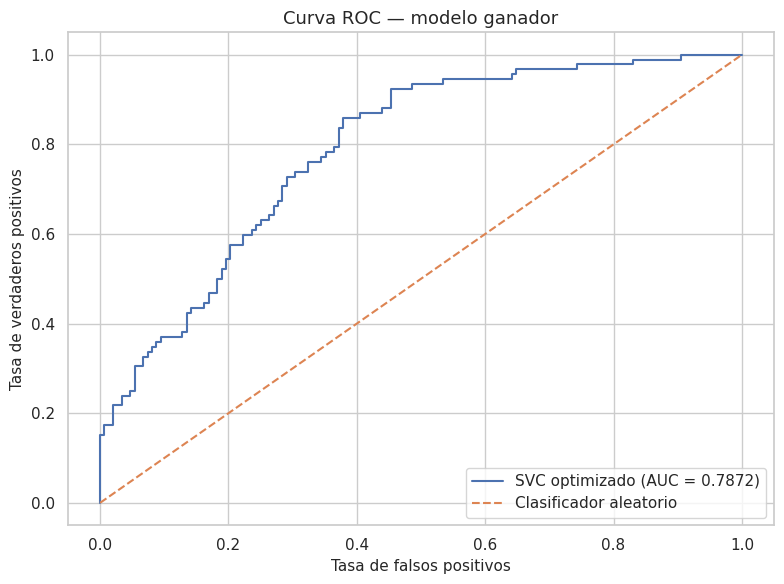

In [56]:
fpr, tpr, thresholds = roc_curve(y_test, y_score_final)
roc_auc_final = roc_auc_score(y_test, y_score_final)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"SVC optimizado (AUC = {roc_auc_final:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC — modelo ganador")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

#### Costo empresarial de los falsos negativos

Los **26 falsos negativos** son clientes que abandonaron sin ser identificados como riesgosos. En un escenario operativo, NovaConecta no les habría ofrecido soporte preventivo, revisión de facturación ni incentivos de retención.

Este error suele ser más costoso que un falso positivo porque puede implicar pérdida de ingresos recurrentes, costos de adquisición para reemplazar al cliente y deterioro de la relación comercial. Aun así, aumentar Recall sin control puede elevar demasiado los falsos positivos. Por ello, la empresa debe definir el umbral de decisión utilizando costos reales de campaña, margen del cliente y pérdida esperada por abandono.

### Interpretabilidad mediante importancia por permutación

SVC con kernel RBF no posee coeficientes directamente interpretables ni `feature_importances_`. Por ello se utiliza **Permutation Importance**, que mide cuánto disminuye el F1 al permutar una variable manteniendo las demás sin cambios.

La importancia se calcula sobre el conjunto de prueba después de cerrar la selección del modelo. Estos resultados describen asociación predictiva; **no prueban causalidad**.

,Variable,Importancia media,Desviación
0,satisfaccion_cliente,0.1258,0.0285
1,antiguedad_meses,0.0944,0.0242
2,uso_datos_gb,0.0260,0.0097
3,plan_contratado,0.0207,0.0059
4,cargo_mensual,0.0169,0.0122
5,num_llamadas_soporte,0.0055,0.0099
6,edad,0.0045,0.0080


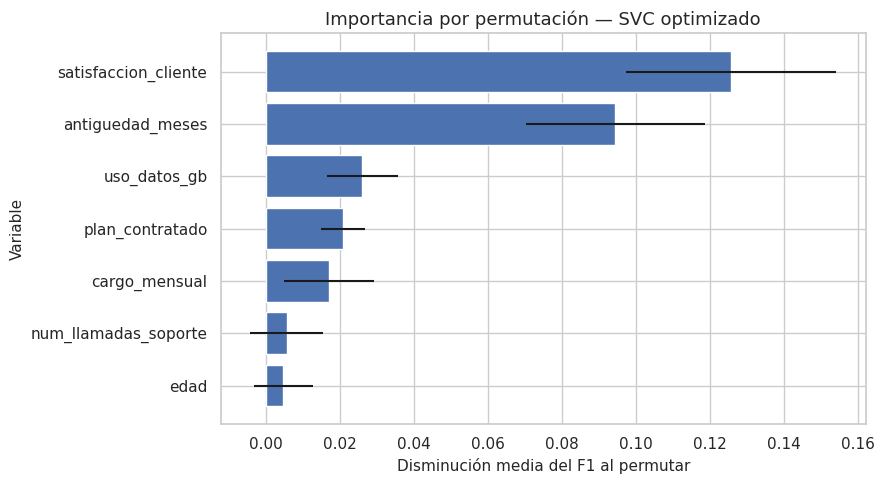

In [57]:
permutation_result = permutation_importance(
    selected_pipeline,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=30,
    random_state=SEED,
    n_jobs=1,
)

importancia_variables_df = (
    pd.DataFrame({
        "Variable": FEATURES,
        "Importancia media": permutation_result.importances_mean,
        "Desviación": permutation_result.importances_std,
    })
    .sort_values("Importancia media", ascending=False)
    .reset_index(drop=True)
)

display(importancia_variables_df.round(4))

plt.figure(figsize=(9, 5))
plt.barh(
    importancia_variables_df["Variable"][::-1],
    importancia_variables_df["Importancia media"][::-1],
    xerr=importancia_variables_df["Desviación"][::-1],
)
plt.xlabel("Disminución media del F1 al permutar")
plt.ylabel("Variable")
plt.title("Importancia por permutación — SVC optimizado")
plt.tight_layout()
plt.show()

#### Variables más influyentes

La importancia por permutación identificó el siguiente orden:

1. **Satisfacción del cliente:** es la variable más influyente. Una satisfacción baja está asociada con mayor riesgo de abandono.
2. **Antigüedad en meses:** los clientes con menor permanencia presentan un patrón de riesgo más alto en el dataset.
3. **Uso de datos:** aporta información adicional sobre el comportamiento y el tipo de servicio utilizado.
4. **Plan contratado:** distingue perfiles de consumo y tarifas; el plan Premium presenta una mayor tasa observada de abandono.
5. **Cargo mensual:** los cargos altos participan en el patrón de abandono, aunque su efecto se comparte con plan y uso.
6. **Llamadas a soporte:** su importancia directa es pequeña porque parte de su información está reflejada en la satisfacción.
7. **Edad:** tiene una contribución predictiva mínima, coherente con la forma independiente en que fue generada.

Las importancias pequeñas o cercanas a cero no significan que una variable nunca sea útil; pueden indicar redundancia, ruido o dependencia de interacciones con otras características.

### Comparación final de todos los modelos

La tabla siguiente incluye los seis modelos base y las versiones optimizadas de los tres candidatos finalistas. La selección principal se mantiene basada en validación cruzada, no en escoger retrospectivamente el mejor resultado del test.

In [58]:
base_final_comparison = resultados_base_df[
    [
        "Modelo",
        "CV Precision media",
        "CV Recall media",
        "CV F1 media",
        "CV F1 desviación",
        "CV ROC-AUC media",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1",
        "Test ROC-AUC",
    ]
].copy()
base_final_comparison.insert(1, "Versión", "Base sin balanceo")

optimized_final_comparison = optimized_results_df[
    [
        "Modelo",
        "CV Precision media",
        "CV Recall media",
        "CV F1 media",
        "CV F1 desviación",
        "CV ROC-AUC media",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1",
        "Test ROC-AUC",
    ]
].copy()
optimized_final_comparison.insert(1, "Versión", "Optimizado + SMOTE")

comparacion_final_df = (
    pd.concat([base_final_comparison, optimized_final_comparison], ignore_index=True)
    .sort_values(["CV F1 media", "CV Recall media"], ascending=False)
    .reset_index(drop=True)
)

display(comparacion_final_df.round(4))

,Modelo,Versión,CV Precision media,CV Recall media,CV F1 media,CV F1 desviación,CV ROC-AUC media,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Support Vector Classifier,Optimizado + SMOTE,0.6477,0.7650,0.7006,0.0247,0.8204,0.7125,0.6055,0.7174,0.6567,0.7872
1,Regresión Logística,Optimizado + SMOTE,0.6496,0.7541,0.6974,0.0277,0.8193,0.7292,0.6286,0.7174,0.6701,0.7927
2,Random Forest,Optimizado + SMOTE,0.6431,0.7131,0.6761,0.0255,0.7998,0.6917,0.5900,0.6413,0.6146,0.7573
3,Regresión Logística,Base sin balanceo,0.7240,0.6339,0.6755,0.0410,0.8199,0.7167,0.6667,0.5217,0.5854,0.7933
4,Support Vector Classifier,Base sin balanceo,0.7283,0.5875,0.6489,0.0274,0.7946,0.7000,0.6515,0.4674,0.5443,0.7817
5,AdaBoost,Base sin balanceo,0.6997,0.5845,0.6356,0.0567,0.8011,0.6958,0.6557,0.4348,0.5229,0.7663
6,Random Forest,Base sin balanceo,0.6520,0.5874,0.6167,0.0207,0.7787,0.6917,0.6324,0.4674,0.5375,0.7392
7,K-Nearest Neighbors,Base sin balanceo,0.6500,0.5545,0.5972,0.0470,0.7336,0.7000,0.6389,0.5000,0.5610,0.7207
8,Árbol de Decisión,Base sin balanceo,0.5286,0.5410,0.5342,0.0172,0.6207,0.6167,0.5000,0.4891,0.4945,0.5925


#### Justificación definitiva del modelo ganador

**SVC optimizado** se conserva como ganador porque obtuvo el mejor rendimiento medio durante la selección realizada con entrenamiento:

- F1 de validación cruzada: **0.7006**.
- Recall de validación cruzada: **0.7650**.
- ROC-AUC de validación cruzada: **0.8204**.
- Brecha Train-CV de F1: **0.0065**, sin señal relevante de sobreajuste.

Regresión Logística obtuvo un F1 de test ligeramente mayor (**0.6701** frente a **0.6567**), pero cambiar el ganador usando esa observación implicaría seleccionar retrospectivamente con el test. Por esa razón, SVC sigue siendo el modelo principal. Regresión Logística se recomienda como alternativa cuando la interpretabilidad operativa sea prioritaria.

## Conclusiones e interpretación de negocio

### Recomendaciones para NovaConecta

1. **Priorizar clientes con satisfacción baja y poca antigüedad.** Son los indicadores predictivos más importantes del modelo.
2. **Crear alertas tempranas después de interacciones de soporte problemáticas.** Aunque las llamadas tienen importancia directa limitada, influyen en la satisfacción.
3. **Revisar la propuesta de valor de los planes con mayor abandono.** El plan Premium presenta la mayor tasa observada y requiere análisis de precio, calidad y expectativas.
4. **Aplicar campañas segmentadas, no descuentos generales.** Los falsos positivos muestran que una intervención tiene costo; conviene combinar la puntuación de riesgo con el valor económico y el margen del cliente.
5. **Definir un umbral según costos reales.** El umbral predeterminado del modelo no necesariamente maximiza el beneficio económico.
6. **Supervisar el rendimiento después del despliegue.** Deben vigilarse Recall, Precision, tasa de abandono y cambios en la distribución de variables.

### Limitaciones

- El dataset es sintético y sus relaciones fueron definidas mediante fórmulas; no sustituye una validación con clientes reales.
- `valor_vida_cliente` fue construido utilizando `abandono` y debió excluirse por fuga de información.
- Los outliers de `cargo_mensual` se agregaron después de generar el objetivo, introduciendo ruido de medición.
- SMOTE se aplicó después de One-Hot Encoding; una observación sintética presentó valores categóricos fraccionarios. `SMOTENC` sería una alternativa futura.
- No existe validación temporal ni externa, por lo que no se ha demostrado generalización ante cambios de mercado.
- El test no participó en GridSearchCV ni en la selección del ganador; sin embargo, fue observado durante la etapa descriptiva de modelos base. Por ello no constituye un holdout totalmente ciego. Una evaluación futura debería reservar un conjunto externo adicional o usar validación anidada.
- La importancia por permutación muestra asociación predictiva, no causalidad.
- No se optimizó el umbral con una función monetaria de costos y beneficios.

### Reproducibilidad e instrucciones de ejecución

#### Ejecución en Visual Studio Code

1. Abrir la raíz del repositorio en VS Code.
2. Crear y activar un entorno virtual.
3. Instalar las dependencias de `requirements.txt`.
4. Abrir `notebooks/Informe_4_Clasificacion.ipynb`.
5. Seleccionar el intérprete del entorno virtual como kernel.
6. Ejecutar **Restart Kernel and Run All**.

#### Ejecución en Google Colab

1. Clonar o subir el repositorio completo.
2. Cambiar el directorio de trabajo a la raíz del repositorio.
3. Instalar `imbalanced-learn` y las dependencias si fueran necesarias.
4. Abrir el notebook y ejecutar todas las celdas en orden.

No debe ejecutarse únicamente una parte del notebook, porque las etapas posteriores reutilizan objetos creados previamente.

In [59]:
import platform
import sys

import imblearn
import joblib
import sklearn

versiones = pd.DataFrame({
    "Componente": [
        "Python",
        "numpy",
        "pandas",
        "matplotlib",
        "seaborn",
        "scikit-learn",
        "imbalanced-learn",
        "joblib",
        "Semilla",
    ],
    "Versión / valor": [
        platform.python_version(),
        np.__version__,
        pd.__version__,
        plt.matplotlib.__version__,
        sns.__version__,
        sklearn.__version__,
        imblearn.__version__,
        joblib.__version__,
        SEED,
    ],
})

versiones

,Componente,Versión / valor
0,Python,3.13.5
1,numpy,2.3.5
2,pandas,2.2.3
3,matplotlib,3.10.8
4,seaborn,0.13.2
5,scikit-learn,1.8.0
6,imbalanced-learn,0.14.1
7,joblib,1.5.3
8,Semilla,42


### Auditoría final de calidad y cumplimiento de la rúbrica

La auditoría verifica el flujo completo, incluyendo prevención de fuga, aislamiento del test durante la búsqueda, balanceo dentro de los folds, rutas portables y cumplimiento funcional del Informe 4.

In [60]:
# Persistencia de los resultados finales adicionales.
metricas_ganador_path = results_dir / "metricas_modelo_ganador.csv"
reporte_clasificacion_path = results_dir / "reporte_clasificacion_final.csv"
importancia_path = results_dir / "importancia_variables_permutacion.csv"
comparacion_final_path = results_dir / "comparacion_final_todos_modelos.csv"
auditoria_path = results_dir / "auditoria_calidad_informe_4.csv"

metricas_ganador.to_csv(metricas_ganador_path, index=False, encoding="utf-8-sig")
reporte_final_df.to_csv(reporte_clasificacion_path, encoding="utf-8-sig")
importancia_variables_df.to_csv(importancia_path, index=False, encoding="utf-8-sig")
comparacion_final_df.to_csv(comparacion_final_path, index=False, encoding="utf-8-sig")

qa_rows = [
    ("Variable objetivo categórica", "Cumple", "abandono codificado como No=0 y Si=1"),
    ("One-Hot Encoding", "Cumple", "plan_contratado se transforma dentro de ColumnTransformer"),
    ("Balanceo de clases", "Cumple", "SMOTE dentro de ImbPipeline y de cada fold"),
    ("Regresión Logística", "Cumple", "Incluida y evaluada"),
    ("Al menos tres modelos adicionales", "Cumple", "KNN, SVC, Árbol de Decisión y Random Forest"),
    ("Modelo de ensamble/boosting", "Cumple", "Random Forest y AdaBoost"),
    ("Ajuste de hiperparámetros", "Cumple", "GridSearchCV con 5 folds y refit por F1"),
    ("Matriz de confusión", "Cumple", "Generada para el SVC optimizado"),
    ("Accuracy, Precision, Recall y F1", "Cumple", "Calculadas sobre el test"),
    ("ROC-AUC y curva ROC", "Cumple", "Calculadas mediante decision_function"),
    ("Data leakage", "Cumple", "valor_vida_cliente excluida de FEATURES y X"),
    ("Split antes del preprocesamiento", "Cumple", "train_test_split precede fit del preprocesador"),
    ("GridSearch sin test", "Cumple", "GridSearchCV se ajusta con X_train e y_train"),
    ("Rutas portables", "Cumple", "Búsqueda relativa desde la raíz o notebooks"),
    ("Interpretabilidad", "Cumple", "Permutation Importance del pipeline ganador"),
    ("Recomendaciones y limitaciones", "Cumple", "Incluidas y vinculadas a resultados"),
    ("Holdout totalmente ciego", "Observación", "El test fue observado en la etapa base, aunque no se usó para seleccionar ni ajustar"),
]

auditoria_df = pd.DataFrame(qa_rows, columns=["Criterio", "Estado", "Evidencia"])
auditoria_df.to_csv(auditoria_path, index=False, encoding="utf-8-sig")

display(auditoria_df)

# Aserciones técnicas finales.
assert TARGET == "abandono"
assert "valor_vida_cliente" not in FEATURES
assert "valor_vida_cliente" not in X.columns
assert TARGET not in X.columns
assert X_train.index.intersection(X_test.index).empty
assert len(X_train) == 960 and len(X_test) == 240
assert list(selected_pipeline.named_steps) == ["preprocessor", "smote", "model"]
assert selected_model_name == "Support Vector Classifier"
assert selected_search.cv.get_n_splits() == 5
assert selected_search.refit == "f1"
assert selected_search.n_splits_ == 5
assert cm_final.sum() == len(y_test)
assert (tn, fp, fn, tp) == (105, 43, 26, 66)
assert np.isclose(metricas_ganador.loc[metricas_ganador["Métrica"] == "F1-Score", "Valor"].iloc[0], 0.6567164179104478)
assert all(path.exists() for path in [
    metricas_ganador_path,
    reporte_clasificacion_path,
    importancia_path,
    comparacion_final_path,
    auditoria_path,
])

print("Auditoría técnica final superada.")
print("El test no participó en GridSearchCV ni en la selección del modelo ganador.")
print("Todos los resultados finales adicionales fueron guardados en:", results_dir)

,Criterio,Estado,Evidencia
0,Variable objetivo categórica,Cumple,abandono codificado como No=0 y Si=1
1,One-Hot Encoding,Cumple,plan_contratado se transforma dentro de Column...
2,Balanceo de clases,Cumple,SMOTE dentro de ImbPipeline y de cada fold
3,Regresión Logística,Cumple,Incluida y evaluada
4,Al menos tres modelos adicionales,Cumple,"KNN, SVC, Árbol de Decisión y Random Forest"
5,Modelo de ensamble/boosting,Cumple,Random Forest y AdaBoost
6,Ajuste de hiperparámetros,Cumple,GridSearchCV con 5 folds y refit por F1
7,Matriz de confusión,Cumple,Generada para el SVC optimizado
8,"Accuracy, Precision, Recall y F1",Cumple,Calculadas sobre el test
9,ROC-AUC y curva ROC,Cumple,Calculadas mediante decision_function


Auditoría técnica final superada.
El test no participó en GridSearchCV ni en la selección del modelo ganador.
Todos los resultados finales adicionales fueron guardados en: /mnt/data/final_repo/Proyecto_IA-master/notebooks/resultados/informe_4


### Conclusiones finales

#### Conclusión técnica

El flujo completo cumplió la rúbrica de clasificación avanzada. Se evaluaron seis algoritmos, se compararon estrategias de balanceo y se optimizaron tres candidatos mediante GridSearchCV. SVC con SMOTE fue seleccionado por obtener el mejor F1 medio de validación cruzada (**0.7006**) y un Recall de **0.7650**, con una brecha Train-CV pequeña.

En el test, el modelo alcanzó Accuracy de **0.7125**, Precision de **0.6055**, Recall de **0.7174**, F1 de **0.6567** y ROC-AUC de **0.7872**. Detectó 66 de los 92 abandonos reales y dejó sin detectar 26.

#### Conclusión de negocio

NovaConecta puede utilizar el modelo como herramienta de priorización para campañas de retención, especialmente sobre clientes con baja satisfacción y poca antigüedad. El modelo no debe automatizar descuentos sin supervisión: las alertas deben combinarse con costos de intervención, valor del cliente y reglas comerciales. Antes de un despliegue real, es necesario validar con datos históricos reales, reservar un holdout externo y establecer un umbral económicamente óptimo.

## Anexo de prompts

El desarrollo del Informe 4 se documentó mediante seis prompts principales:

| N.° | Etapa documentada |
|---|---|
| P-01 | Auditoría técnica del dataset y diseño metodológico |
| P-02 | EDA, selección de variables y preprocesamiento |
| P-03 | Entrenamiento y comparación de modelos base |
| P-04 | Análisis del desbalance y comparación de estrategias |
| P-05 | Ajuste de hiperparámetros y selección del modelo |
| P-06 | Evaluación final, interpretabilidad y auditoría de calidad |

El texto literal de cada prompt, sus resultados y las validaciones realizadas se entregan en los archivos:

- `entregables_finales/Registro_de_prompts_Aldana_COMPLETADO.xlsx`
- `entregables_finales/Registro_Prompts_Aldana.md`

Estos registros permiten demostrar cómo se utilizó la inteligencia artificial, qué resultados se incorporaron al proyecto y qué comprobaciones técnicas se efectuaron antes de aceptar cada resultado.